# Reaction-Diffusion Model (Initial Coding task) (Subrata T)

## 0. Computational Environment (Thanks to UN Chicago)

| System | CPU | GPU | C / C++ |
|---|---|---|---|
| Linux / x86_64 | 128 cores | NVIDIA A100-SXM4-40GB | GCC / G++ |

| Scientific | Numerical / ML | Parallel | Build |
|---|---|---|---|
| NumPy · SciPy · SymPy | Scikit-learn · JAX · Numba | OpenMPI · MPI4Py · Dask | CMake · Make · Ninja |

| Data | Visualization | Optimization | Python / CUDA |
|---|---|---|---|
| HDF5 · Zarr · PyArrow | Matplotlib · IPyMPL | LMFIT | 3.11 · PyTorch CUDA 12.1 |

## 1. Objective

The objective of this task is to:

1. Isolate the Reaction–Diffusion (RD) equations from Part I of the assigned paper.
2. Implement the RD model in C.
3. Generate the corresponding stress and recovery results using the parameters provided in the paper.
4. Validate the implementation against the reported model behavior.

## References

**[1]** S. Mahapatra, A. Ansari, A. S. Bisht, N. Choudhury, N. Parihar,
P. Chatterjee, P. Gholve, R. Tiwari, S. Kumar, and T. Samadder,
“A Generic Trap Generation Framework for MOSFET Reliability—Part I:
Gate Only Stress–BTI, SILC, and TDDB,”
*IEEE Transactions on Electron Devices*, vol. 71, no. 1,
pp. 114–125, 2024.
DOI: [10.1109/TED.2023.3291333](https://doi.org/10.1109/TED.2023.3291333)

**[2]** S. Mahapatra, H. Diwakar, K. Thakor, N. Choudhury, P. Chatterjee,
S. Kumar, U. Singhal, and U. Sharma,
“A Generic Framework for MOSFET Reliability—Part II:
Gate and Drain Stress—HCD,”
*IEEE Transactions on Electron Devices*, vol. 71, no. 1,
pp. 126–137, 2024.
DOI: [10.1109/TED.2023.3308526](https://doi.org/10.1109/TED.2023.3308526)

**[3]** S. Mahapatra, *Negative Bias Temperature Instability
(NBTI): Physics, Modeling, and Simulation*,
Springer, 2022.

**[4]** Wikipedia contributors,
“Diffusion,” *Wikipedia, The Free Encyclopedia*.
Available: https://en.wikipedia.org/wiki/Diffusion

<div style="text-align:center; margin-bottom:25px;">

# 2. Physical Basis of the Reaction–Diffusion (RD) Model

</div>

The Reaction–Diffusion (RD) model describes the time evolution of
interface-trap density, $N_{IT}$, during electrical stress and the
subsequent recovery process.

In an NBTI experiment, a negative gate voltage is applied to a p-channel
MOSFET at elevated temperature. This condition is referred to as the
**stress phase**. The purpose of the stress is to accelerate the
depassivation of hydrogen-passivated defects at the Si/IL interface,
thereby generating interface traps. The resulting increase in
interface-trap density represents the degradation of the device under
NBTI stress.

After a prescribed stress duration, the electrical stress is removed and
the device is placed in the **recovery phase**. During recovery, the
hydrogen-related processes proceed in the reverse direction, allowing a
fraction of the generated interface traps to become re-passivated.
Therefore, the stress and recovery phases together describe the
time-dependent degradation and recovery of the device.

---

<div style="
    background-color:#f5f7fa;
    border-left:5px solid #4a6fa5;
    padding:14px 18px;
    margin:20px 0;
    border-radius:5px;
">

<strong>Physical picture of the RD model</strong><br><br>

During <strong>stress</strong>, hydrogen-passivated defects are
depassivated, generating interface traps and releasing atomic hydrogen
($H$). The released hydrogen diffuses through the gate-insulator region
and participates in defect-assisted formation of molecular hydrogen
($H_2$).

During <strong>recovery</strong>, the hydrogen-related processes proceed
in the reverse direction, contributing to the re-passivation of
previously generated interface traps.

</div>

For the dual-layer HKMG gate stack considered in this work, the RD model
uses two effective interfaces:

1. **Interface 1:** Channel/Interlayer (IL) interface.
2. **Interface 2:** IL/High-K interface, representing the distributed
   hydrogen-passivated defects in the gate-insulator bulk.

The physical representation of these processes is shown in Fig. 2.1.

<div style="text-align:center; margin:25px 0;">

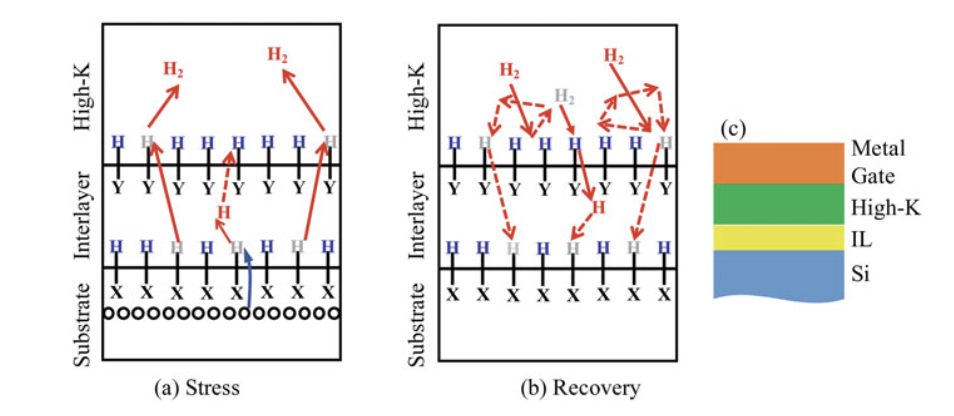

<br>

<span style="font-size:0.90em; color:#555;">
<strong>Figure 2.1.</strong>
Schematic representation of the Reaction–Diffusion (RD) model during
stress and recovery for an HKMG gate-insulator stack. During stress,
hydrogen-related depassivation generates interface traps and releases
atomic hydrogen, which diffuses through the gate-insulator region and
participates in defect-assisted formation of molecular hydrogen
($H_2$). During recovery, the reverse hydrogen-related processes
contribute to re-passivation of the generated interface traps. Adapted
from [3].
</span>

</div>

The two interface-trap densities are denoted by
$N_{IT}^{(1)}$ and $N_{IT}^{(2)}$.

The total interface-trap density used in the present implementation is

$$
N_{IT}=N_{IT}^{(1)}+N_{IT}^{(2)}.
$$

The RD model describes how hydrogen-related reactions and the movement of hydrogen through the gate-insulator region together influence the generation and recovery of interface traps.

The model is based on the **defect-assisted dimerization** mechanism.
Atomic hydrogen released during defect depassivation participates in the
formation of molecular hydrogen, while the transport of $H$ and $H_2$
through the gate-insulator region determines their availability at the
reaction interfaces [3].

In the numerical implementation developed in this work, the stress phase
is first simulated to generate the interface-trap population and
hydrogen concentration profiles. The state obtained at the end of the
stress period is then used as the initial condition for the subsequent
recovery simulation.

<div style="
    background-color:#eef4fb;
    border:1px solid #c9d8ea;
    padding:12px 16px;
    margin-top:22px;
    border-radius:5px;
">

<!-- <strong>Reference</strong><br><br>

[3] S. Mahapatra (Ed.), <em>Recent Advances in PMOS Negative Bias
Temperature Instability: Characterization and Modeling of Device
Architecture, Material and Process</em>, Springer, 2022.

</div> -->

## 2.1 From the RDD Framework to the RD Model

The assigned reliability framework contains several physical mechanisms
that contribute to MOSFET degradation. For the present coding task, the
focus is on the **Reaction--Diffusion (RD) model**, which describes the
generation and passivation of interface traps during and after electrical
stress.

The RD model is part of the broader Reaction--Diffusion--Drift (RDD)
framework [1]. The two models share the basic hydrogen-related reaction and
diffusion processes, but the RDD model additionally includes the generation
and transport of ionic hydrogen species.

Therefore, before implementing the equations, the required RD processes
are separated from the additional RDD processes.

### 2.1.1 Physical Processes Included in the RD Model

For the HKMG structure considered here, the RD model describes the
generation and passivation of interface traps through hydrogen-related
reactions.

The model uses two effective interfaces:

1. **Interface 1:** Channel/IL interface.
2. **Interface 2:** IL/High-K interface.

Although the hydrogen-passivated defects represented by the second
interface are physically distributed through the gate-insulator bulk,
they are grouped at the IL/High-K interface to simplify the model.

The main physical sequence during stress is

$$
\text{Trap dissociation}
\rightarrow
H\text{ release}
\rightarrow
H\text{ diffusion}
\rightarrow
H_2\text{ formation}
\rightarrow
H_2\text{ diffusion}.
$$

During recovery, the corresponding reverse processes occur:

$$
H_2\text{ diffusion back}
\rightarrow
H\text{ generation}
\rightarrow
\text{trap passivation}.
$$

This defect-assisted dimerization version of the RD model is the model
used in the present implementation.

### 2.1.2 RD Model Schematic

The following schematic illustrates the physical picture used by the
RD model for a dual-layer HKMG gate stack.

<div style="text-align:center; margin:15px 0;">

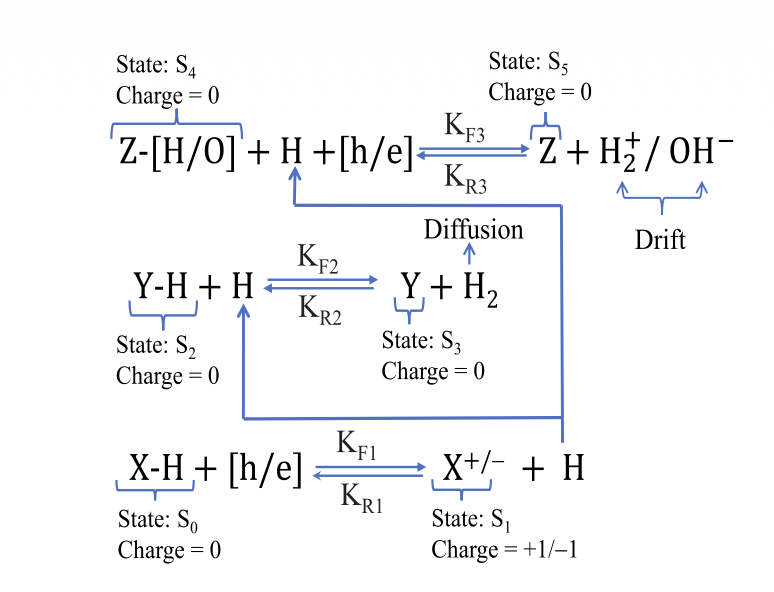
<p style="font-size:0.9em; color:#555;">
Figure 2.1. Schematic of the Reaction--Diffusion (RD) model with
defect-assisted dimerization during stress and the reverse processes
during recovery for an HKMG gate-insulator stack.
</p>

</div>

The figure provides the physical basis for the equations implemented
below. During stress, hydrogen is released from hydrogen-passivated
defects at the channel/IL interface. The released atomic hydrogen
diffuses through the gate stack and participates in a defect-assisted
reaction at the second effective interface, producing molecular
hydrogen. During recovery, the reverse diffusion and reaction processes
lead to trap passivation.

### 2.1.3 Processes Excluded from the Present Implementation

The complete RDD formulation contains additional processes involving
ionic hydrogen species, particularly $H_2^+$, together with their
drift under an electric field.

These processes are not required for the present RD implementation.

Therefore, the following are excluded:

- generation of ionic $H_2^+$ species,
- drift of $H_2^+$ under the electric field, and
- the corresponding ionic-species transport equations.

The neutral hydrogen-related processes are retained:

- interface-trap generation,
- atomic-hydrogen diffusion,
- defect-assisted formation of $H_2$,
- molecular-hydrogen diffusion, and
- reverse reactions during recovery.

Thus, the present model can be viewed schematically as

$$
\boxed{
\text{RDD framework}
\;\longrightarrow\;
\text{remove ionic-species processes}
\;\longrightarrow\;
\text{RD model🤔}
}
$$



### 2.1.4 Stress and Recovery

The RD model is evaluated in two stages: **stress** and **recovery**.

During stress, an applied gate bias promotes the dissociation of
hydrogen-passivated defects at the channel/IL interface. This produces
interface traps and releases atomic hydrogen. The released hydrogen then
diffuses through the gate-insulator stack and participates in subsequent
reactions.

The interface-trap density therefore increases with stress time.

During recovery, the stress bias is removed. The hydrogen species undergo
reverse transport and reaction processes, allowing some of the generated
interface traps to become passivated again.

The model therefore provides two quantities of interest:

$$
N_{IT}^{(1)}(t)
$$

for the first interface and

$$
N_{IT}^{(2)}(t)
$$

for the second interface.

The total interface-trap density used in the present implementation is

$$
N_{IT}(t)
=
N_{IT}^{(1)}(t)
+
N_{IT}^{(2)}(t).
$$

The stress and recovery simulations are therefore solved separately but
remain physically connected through the hydrogen concentrations produced
during the preceding stage.

### 2.1.5 Governing Equations Required for the Implementation

After identifying the physical processes that belong to the RD model,
the governing equations can be grouped into three coupled parts:

1. **Interface-trap reaction equations**
   - describe trap generation and passivation.

2. **Atomic-hydrogen diffusion equation**
   - describes the transport of released $H$ through the interlayer.

3. **Molecular-hydrogen reaction and diffusion equations**
   - describe the formation of $H_2$ at the second interface and its
     subsequent transport through the gate-insulator region.

The equations are coupled because the reaction rates depend on the local
hydrogen concentrations, while the hydrogen concentrations are themselves
affected by the reactions.

The implementation therefore solves a coupled reaction--diffusion problem
rather than treating trap generation and hydrogen transport independently.

### 2.2.1 Governing Equation: Trap Generation at Interface 1

The first effective interface corresponds to the **channel/IL interface**.
During stress, hydrogen-passivated defects at this interface are
dissociated, generating interface traps and releasing atomic hydrogen.
During recovery, the reverse reaction allows the generated traps to become
re-passivated.

The corresponding trap-generation/passivation equation is

$$
\frac{dN_{IT}^{(1)}}{dt}
=
K_{F1}
\left(
N_{0}^{(1)}-N_{IT}^{(1)}
\right)
-
K_{R1}
N_{IT}^{(1)}
N_H^{(1)}
\tag{2.1}
$$

The equation represents the balance between **trap generation** and
**trap passivation**:

$$
\boxed{
\frac{dN_{IT}^{(1)}}{dt}
=
\text{generation rate}
-
\text{passivation rate}
}
$$

### Generation term

$$
K_{F1}
\left(
N_{0}^{(1)}-N_{IT}^{(1)}
\right)
$$

where

- $N_{0}^{(1)}$: initial density of H-passivated defects at the first
  interface.
- $N_{IT}^{(1)}$: interface-trap density generated at the first interface.
- $N_{0}^{(1)}-N_{IT}^{(1)}$: remaining passivated defects available for
  dissociation.
- $K_{F1}$: forward reaction rate constant for defect dissociation.

The forward process can be represented schematically as

$$
\mathrm{X-H \rightarrow X^{\bullet}+H}
$$

where $X$ represents the defect site at the channel/IL interface.

The generation rate is proportional to the number of remaining
H-passivated defects. Therefore, as more defects are dissociated,
the available population decreases through the factor

$$
N_{0}^{(1)}-N_{IT}^{(1)}.
$$

<div style="color:#16803c; background:#f0fdf4; border-left:4px solid #22c55e; padding:8px 12px; margin:10px 0;">

<b>Physical intuition:</b> The term behaves mathematically like a
depletion process: the more passivated defects that have already been
dissociated, the fewer remain available for further trap generation.
This does not imply radioactive decay; the underlying physical process
is hydrogen-passivated defect dissociation.

</div>

### Passivation term

$$
K_{R1}
N_{IT}^{(1)}
N_H^{(1)}
$$

where

- $K_{R1}$: reverse/passivation reaction rate constant.
- $N_{IT}^{(1)}$: density of available interface traps at interface 1.
- $N_H^{(1)}$: atomic-hydrogen density at the first interface.

The reverse reaction can be represented as

$$
\mathrm{X^{\bullet}+H \rightarrow X-H}.
$$

The reaction requires both an available interface trap and atomic
hydrogen. Therefore, using the mass-action form,

$$
\text{passivation rate}
\propto
N_{IT}^{(1)}N_H^{(1)}.
$$

This term is subtracted from the governing equation because
re-passivation reduces the number of active interface traps.

<div style="color:#16803c; background:#f0fdf4; border-left:4px solid #22c55e; padding:8px 12px; margin:10px 0;">

<b>Connection to diffusion:</b> The atomic-hydrogen density
$N_H^{(1)}$ is not an independent constant. It is obtained from the
hydrogen transport equation and therefore couples the interface
reaction to the diffusion part of the RD model.

</div>

### Units

<div style="color:#16803c; background:#f0fdf4; border-left:4px solid #22c55e; padding:8px 12px; margin:10px 0;">

<b>Dimensional check</b>

$$
N_{IT}^{(1)},N_{0}^{(1)}
:\mathrm{cm^{-2}},
\qquad
N_H^{(1)}
:\mathrm{cm^{-3}}.
$$

Therefore,

$$
K_{F1}:\mathrm{s^{-1}},
\qquad
K_{R1}:\mathrm{cm^3\,s^{-1}}.
$$

For the generation term,

$$
K_{F1}
\left(
N_{0}^{(1)}-N_{IT}^{(1)}
\right)
\sim
\mathrm{s^{-1}}\times\mathrm{cm^{-2}}
=
\mathrm{cm^{-2}s^{-1}}.
$$

For the passivation term,

$$
K_{R1}
N_{IT}^{(1)}
N_H^{(1)}
\sim
\mathrm{cm^3s^{-1}}
\times
\mathrm{cm^{-2}}
\times
\mathrm{cm^{-3}}
=
\mathrm{cm^{-2}s^{-1}}.
$$

Thus, both terms have the same units as

$$
\frac{dN_{IT}^{(1)}}{dt}
:
\mathrm{cm^{-2}s^{-1}}.
$$

</div>

The dependence on $N_H^{(1)}$ connects the first-interface reaction
directly to the atomic-hydrogen diffusion equation introduced in the
next section.

### 2.2.2 Reaction at the IL/High-K Interface

The second effective interface represents the hydrogen-passivated
defects that are distributed throughout the gate-insulator bulk. In the
present one-dimensional implementation, these defects are lumped at the
IL/High-K interface for simplicity.

The corresponding trap kinetics are described by

$$
\frac{dN_{IT}^{(2)}}{dt}
=
K_{F2}
\left(
N_{0}^{(2)}-N_{IT}^{(2)}
\right)
N_H^{(2)}
-
K_{R2}
N_{IT}^{(2)}
N_{H_2}^{(2)}
\tag{2.2}
$$

where

- $N_{0}^{(2)}$: initial density of H-passivated defects associated with
  the second effective interface.
- $N_{IT}^{(2)}$: interface-trap density associated with the second
  effective interface.
- $N_H^{(2)}$: atomic-H concentration at the second interface.
- $N_{H_2}^{(2)}$: molecular-H$_2$ concentration at the second interface.
- $K_{F2}$: forward reaction rate constant.
- $K_{R2}$: reverse reaction rate constant.

The equation again represents a balance between trap generation and
passivation:

$$
\boxed{
\frac{dN_{IT}^{(2)}}{dt}
=
\text{generation rate}
-
\text{passivation rate}
}
$$

### Generation and H$_2$ formation

The forward term is

$$
K_{F2}
\left(
N_{0}^{(2)}-N_{IT}^{(2)}
\right)
N_H^{(2)}.
$$

Here, the remaining H-passivated defects are represented by

$$
N_{0}^{(2)}-N_{IT}^{(2)}.
$$

The released atomic hydrogen reaching the second effective interface
reacts with these passivated defects. This is the **defect-assisted
dimerization** process, in which the reaction produces molecular
hydrogen:

$$
\mathrm{Y-H + H \rightarrow Y^{\bullet} + H_2}.
$$

Thus, unlike the first-interface reaction, the second-interface reaction
directly connects trap generation with the formation of molecular
hydrogen.

<div style="color:#16803c; background:#f0fdf4; border-left:4px solid #22c55e; padding:8px 12px; margin:10px 0;">

<b>Physical intuition:</b> The first interface releases atomic H during
stress. The H atoms then diffuse through the gate-insulator region.
When they reach H-passivated defects represented by the second effective
interface, they can participate in the defect-assisted reaction that
produces H$_2$.

</div>

### Passivation term

The reverse term is

$$
K_{R2}
N_{IT}^{(2)}
N_{H_2}^{(2)}.
$$

The reverse reaction can be represented schematically as

$$
\mathrm{Y^{\bullet}+H_2 \rightarrow Y-H+H}.
$$

The passivation rate therefore depends on both the available traps and
the local molecular-hydrogen concentration:

$$
\text{passivation rate}
\propto
N_{IT}^{(2)}N_{H_2}^{(2)}.
$$

This term is subtracted because the reverse process reduces the
population of active interface traps.

<div style="color:#16803c; background:#f0fdf4; border-left:4px solid #22c55e; padding:8px 12px; margin:10px 0;">

<b>Important distinction:</b> The second interface is an effective
representation rather than a statement that all physical Y-H defects
are located exactly at the IL/High-K boundary. The reference explicitly
lumps the distributed bulk defects at this interface to simplify the
one-dimensional RD description.

</div>

### Connection with the diffusion model

The second-interface equation provides the coupling between atomic-H
transport and molecular-H$_2$ transport.

The forward reaction consumes atomic H and generates H$_2$, while the
reverse reaction consumes H$_2$ and contributes to trap passivation.

Therefore, the second interface acts as the connection between the two
transport processes:

$$
H
\quad\longrightarrow\quad
\text{defect-assisted reaction}
\quad\longrightarrow\quad
H_2.
$$

The generated H$_2$ subsequently diffuses into the gate-insulator bulk,
where its transport becomes increasingly important at longer stress
times.

<div style="color:#1d4ed8; background:#eff6ff; border-left:4px solid #3b82f6; padding:8px 12px; margin:10px 0;">

<b>Connection to the expected time dependence:</b> The RD model has
different dominant mechanisms at different time scales. The first
interface reaction is dominant at short times, defect-assisted
dimerization at the second interface becomes important at intermediate
times, and molecular-H$_2$ diffusion controls the long-time regime.
Therefore, this second-interface equation is essential for reproducing
the transition toward the long-time RD behavior.

</div>

### Units

<div style="color:#16803c; background:#f0fdf4; border-left:4px solid #22c55e; padding:8px 12px; margin:10px 0;">

<b>Dimensional check</b>

$$
N_{IT}^{(2)},N_{0}^{(2)}
:\mathrm{cm^{-2}},
$$

and

$$
N_H^{(2)},N_{H_2}^{(2)}
:\mathrm{cm^{-3}}.
$$

Therefore,

$$
K_{F2},K_{R2}
:\mathrm{cm^3\,s^{-1}}.
$$

For the forward term,

$$
K_{F2}
\left(
N_{0}^{(2)}-N_{IT}^{(2)}
\right)
N_H^{(2)}
\sim
\mathrm{cm^3s^{-1}}
\times
\mathrm{cm^{-2}}
\times
\mathrm{cm^{-3}}
=
\mathrm{cm^{-2}s^{-1}}.
$$

Similarly,

$$
K_{R2}
N_{IT}^{(2)}
N_{H_2}^{(2)}
\sim
\mathrm{cm^{-2}s^{-1}}.
$$

Thus, both terms have the required units of

$$
\frac{dN_{IT}^{(2)}}{dt}
:
\mathrm{cm^{-2}s^{-1}}.
$$

</div>

The second-interface reaction therefore provides the physical link
between atomic-H diffusion, H$_2$ formation, and subsequent molecular-H$_2$
diffusion in the RD model.

### 2.2.3 Reaction-Rate Constants and Their Physical Origin

The coefficients $K_{F1}$, $K_{F2}$, $K_{R1}$, and $K_{R2}$ determine how
rapidly the corresponding chemical reactions occur. They therefore provide
the connection between the physical reaction mechanism and the time
evolution of the interface-trap densities.

The RD equations contain two types of reaction rates:

1. the forward rates $K_{F1}$ and $K_{F2}$, which describe trap generation
   and the associated hydrogen reactions, and
2. the reverse rates $K_{R1}$ and $K_{R2}$, which describe trap
   passivation during the reverse reactions.

The reference treats these rates differently because the physical origin
of the first-interface dissociation is different from that of the other
RD reactions.

In particular, $K_{F1}$ describes the dissociation of H-passivated
defects at the channel/IL interface. This process is assisted by
inversion-layer holes and the oxide electric field during electrical
stress.

In contrast, the second-interface reaction and the reverse reactions are
treated as thermally activated processes and do not have the same direct
stress-voltage dependence.

This distinction is important for the numerical implementation because
$K_{F1}$ must be calculated from the applied stress conditions, whereas
the other reaction rates can be calculated from their temperature
dependence.

### 2.2.4 Process-Independent and Process-Dependent Parameters

The RD model parameters are divided into two groups according to whether
they are kept common across different device technologies or need to be
adjusted according to the particular device process and material system.

This distinction is important because not every parameter in the RD model
is obtained in the same way.

#### Process-independent parameters

The reference defines the process-independent parameters as parameters
that are kept common when the RD model is applied to different devices.
These parameters are thermally activated and are described using the
Arrhenius relation

$$
X
=
X_0
\exp\left(
-\frac{E_A}{k_BT}
\right),
$$

where

- $X$ is the temperature-dependent parameter,
- $X_0$ is its pre-factor,
- $E_A$ is its temperature activation energy,
- $k_B$ is the Boltzmann constant, and
- $T$ is the absolute temperature.

For the present RD model, the process-independent reaction parameters
are

$$
K_{F2}
=
K_{F2,0}
\exp\left(
-\frac{E_{A,KF2}}{k_BT}
\right),
$$

$$
K_{R1}
=
K_{R1,0}
\exp\left(
-\frac{E_{A,KR1}}{k_BT}
\right),
$$

and

$$
K_{R2}
=
K_{R2,0}
\exp\left(
-\frac{E_{A,KR2}}{k_BT}
\right).
$$

The reference also treats the hydrogen and molecular-hydrogen
diffusivities as process-independent Arrhenius parameters.

The values listed in Table 4.1 are

| Parameter | Unit | Pre-factor | $E_A$ (eV) |
|---|---|---:|---:|
| $K_{F2}$ | $\mathrm{cm^3\,s^{-1}}$ | $5750$ | $0.235$ |
| $K_{R1}$ | $\mathrm{cm^3\,s^{-1}}$ | $5\times10^{-6}$ | $0.12$ |
| $K_{R2}$ | $\mathrm{cm^3\,s^{-1}}$ | $7.5\times10^{-4}$ | $0.20$ |
| $D_H$ | $\mathrm{cm^2\,s^{-1}}$ | $2\times10^{-2}$ | $0.20$ |
| $D_{H_2}$ | $\mathrm{cm^2\,s^{-1}}$ | $9.5\times10^{-11}$ | $0.50$ |

For $D_H$ and $D_{H_2}$, the reference gives separate pre-factors for
the IL/High-K region and the region beyond it. These will be introduced
when the spatial diffusion model is formulated.

Thus, once the temperature is specified, these parameters can be
calculated directly from their tabulated pre-factors and activation
energies.

<div style="color:#16803c; background:#f0fdf4; border-left:4px solid #22c55e; padding:8px 12px; margin:10px 0;">

<b>Meaning of process-independent:</b> "Process-independent" does not
mean that the parameter is independent of temperature. In the RD
framework, these parameters are still temperature dependent through the
Arrhenius relation. It means that the same parameter set is used across
the different devices considered in the reference.

</div>

#### Process-dependent parameters

The first-interface forward reaction is different.

The dissociation of the H-passivated defect at the channel/IL interface
is assisted by inversion-layer holes and the oxide electric field. The
corresponding forward rate $K_{F1}$ therefore depends on the electrical
stress condition as well as on device and material properties.

The reference writes the first-interface rate in terms of

$$
K_{F1}
=
K_{F10}
\exp(\Delta_E E_{OX})
\exp\left(
-\frac{E_{A,KF1}}{k_BT}
\right),
$$

with

$$
\Delta_E
=
\Delta_0
+
\frac{\alpha}{k_BT}.
$$

Therefore,

$$
K_{F1}
=
K_{F10}
\exp
\left[
\left(
\Delta_0+\frac{\alpha}{k_BT}
\right)
E_{OX}
\right]
\exp
\left(
-\frac{E_{A,KF1}}{k_BT}
\right).
$$

The parameters

$$
K_{F10},\qquad
\Delta_0,\qquad
\alpha,\qquad
E_{A,KF1}
$$

are classified by the reference as **process-dependent RD model
parameters**.

These parameters describe the inversion-layer-hole-assisted
dissociation process at the first interface. In particular, $K_{F10}$
depends on quantities such as the hole density, hole tunneling
probability, tunneling coefficient, and capture cross section. The
tunneling-related quantities are themselves influenced by the tunneling
effective mass and barrier height.

Consequently, changes in the channel material, gate-insulator process,
nitrogen concentration, or mechanical strain can modify the first
interface reaction parameters.

<div style="color:#1d4ed8; background:#eff6ff; border-left:4px solid #3b82f6; padding:8px 12px; margin:10px 0;">

<b>Important distinction:</b> $K_{F1}$ is not simply a fixed
process-dependent constant. Rather, its value is calculated from the
process-dependent parameters together with the operating conditions,
particularly $E_{OX}$ and $T$.

</div>

For example, the reference gives different values of
$K_{F10}$, $\Delta_0$, and $E_{A,KF1}$ for different device/process
combinations. This is why the first-interface reaction must be treated
separately from the process-independent reaction rates.

### Summary

The parameter classification can therefore be summarized as follows:

| Parameter group | Examples | Main dependence |
|---|---|---|
| Process-independent | $K_{F2}$, $K_{R1}$, $K_{R2}$, $D_H$, $D_{H_2}$ | Temperature through Arrhenius law |
| Process-dependent | $K_{F10}$, $\Delta_0$, $\alpha$, $E_{A,KF1}$ | Device/process/material properties |
| Calculated first-interface rate | $K_{F1}$ | Process-dependent parameters + $E_{OX}$ + $T$ |

This classification will be used directly in the numerical
implementation. The process-independent parameters can be taken from
the reference table, while the first-interface parameters must be
specified for the particular device being modeled.

## 2.3 Simulation Setup and Initial Conditions

Before solving the coupled reaction--diffusion equations, the physical
parameters of the device and the operating conditions must be specified.

The simulation is divided into two stages:

1. **Stress:** an electrical stress is applied to generate interface traps.
2. **Recovery:** the stress is removed and the reverse reactions are
   followed using the state reached at the end of stress.

The purpose of this section is to establish the initial state and the
parameters that remain fixed during each simulation stage.

### 2.3.1 Device Parameters and Simulation Conditions

The numerical simulation is initialized using a combination of
device-specific parameters, process-independent RD parameters, and
externally specified stress conditions.

For the present implementation, the **D1 device** is used as the
reference device. In the assigned book, D1 is a planar Si-channel device
with a thermal IL and low nitrogen concentration in the gate stack.
The process-dependent RD parameters for D1 are listed in Table 4.2 of
the reference.

<div style="color:#1d4ed8; background:#eff6ff; border-left:4px solid #3b82f6; padding:8px 12px; margin:10px 0;">

<b>Reference device: D1</b>

The D1 device is a planar device with a Si channel, thermal IL, and
low nitrogen concentration. It is used here as the reference device
for establishing the first-interface RD parameters.

</div>

#### Device and structural parameters

The simulation requires the dimensions of the gate-insulator regions:

$$
L_{IL}=1.5\ \mathrm{nm},
\qquad
L_{HK}=30\ \mathrm{nm}.
$$

These values define the spatial domains used in the present numerical
implementation. The corresponding values in centimetres are

$$
L_{IL}=1.5\times10^{-7}\ \mathrm{cm},
$$

and

$$
L_{HK}=30\times10^{-7}\ \mathrm{cm}.
$$

The spatial discretization is then introduced later by dividing these
domains into numerical grid cells.

<div style="color:#a16207; background:#fefce8; border-left:4px solid #eab308; padding:8px 12px; margin:10px 0;">

<b>Implementation note:</b> The above spatial dimensions define the
numerical gate-stack domain used in this work. They should therefore be
distinguished from the RD kinetic parameters tabulated for D1 in the
reference.

</div>

#### Interface-trap precursor densities

The initial density of H-passivated defects at the channel/IL interface
is represented by

$$
N_{0}^{(1)}
=
5\times10^{12}\ \mathrm{cm^{-2}}.
$$

The reference states that $N_{0}^{(1)}$ is device and process dependent:
it varies with factors such as channel orientation, gate-stack thermal
budget, and Ge concentration. For a Si channel with a thermal or
low-temperature chemical-oxide IL on the (100) surface, the book uses

$$
N_{0}^{(1)}
=
5\times10^{12}\ \mathrm{cm^{-2}}
$$

throughout the relevant examples.

The corresponding precursor density associated with the second effective
interface is

$$
N_{0}^{(2)}
=
5\times10^{13}\ \mathrm{cm^{-2}}.
$$

Unlike $N_{0}^{(1)}$, the reference takes $N_{0}^{(2)}$ as
$5\times10^{13}\ \mathrm{cm^{-2}}$ for all cases considered.

Therefore, the initial available passivated-defect populations used in
the present simulation are

$$
N_{0}^{(1)}
=
5\times10^{12}\ \mathrm{cm^{-2}},
$$

$$
N_{0}^{(2)}
=
5\times10^{13}\ \mathrm{cm^{-2}}.
$$

At the beginning of the stress simulation,

$$
N_{IT}^{(1)}(0)=0,
\qquad
N_{IT}^{(2)}(0)=0.
$$

Consequently, initially,

$$
N_{0}^{(1)}-N_{IT}^{(1)}=N_{0}^{(1)}
$$

and

$$
N_{0}^{(2)}-N_{IT}^{(2)}=N_{0}^{(2)}.
$$

Thus, the simulation starts with the complete population of
H-passivated precursor defects available for the stress-induced
reactions.

The dependence of $N_{0}^{(1)}$ on device and process conditions, and
the use of $5\times10^{13}\ \mathrm{cm^{-2}}$ for $N_{0}^{(2)}$, are
specified in the reference discussion accompanying Table 4.1. 

### 2.3.2 D1-Specific First-Interface Parameters

For the D1 reference device, the process-dependent RD parameters are
obtained from Table 4.2 of the reference.

The D1 values are

$$
K_{F10}=0.22\ \mathrm{cm/V\,s},
$$

$$
E_{A,KF1}=0.40\ \mathrm{eV},
$$

$$
\Delta_0=0.38\ \mathrm{cm/MV},
$$

and

$$
\alpha=1.2\ q\mathrm{\AA}.
$$

These parameters describe the inversion-layer-hole-assisted
dissociation of the H-passivated defects at the channel/IL interface.

The first-interface forward reaction rate is therefore calculated from

$$
K_{F1}
=
K_{F10}
\exp
\left[
\left(
\Delta_0+
\frac{\alpha}{k_BT}
\right)E_{OX}
\right]
\exp
\left(
-\frac{E_{A,KF1}}{k_BT}
\right).
$$

For a fixed D1 device, fixed temperature, and fixed stress electric
field, these quantities are fixed during the stress simulation.
Consequently, $K_{F1}$ is calculated before the time-stepping loop and
is not updated at every time step.

The book gives the D1 values in Table 4.2 and identifies these parameters
as the process-dependent parameters associated with the
inversion-layer-hole-assisted bond-dissociation process. 

In [1]:
#include <stdio.h>
#include <math.h>

In [2]:
double calculate_KF1(
    double T_K,
    double EOX,
    double KF10,
    double Delta0,
    double alpha,
    double EA_KF1)
{
    const double kB = 8.617333262e-5;
    const double ANGSTROM_MV_CM_TO_V = 0.01; // do the calculation calculation 

    double kT = kB * T_K;

    double DeltaE =
        Delta0
        + (alpha * ANGSTROM_MV_CM_TO_V) / kT;

    return KF10
           * exp(EOX * DeltaE)
           * exp(-EA_KF1 / kT);
}

In [3]:
// printf("KF1 = %.10e\n", calculate_KF1(398.15, 7.0, 0.22, 0.38, 1.2, 0.40)); //lets see hwta comes ,perfect 

### 2.3.3 Operating Conditions

After defining the device and process parameters, the external operating
conditions for the simulation are specified.

The main simulation conditions are the temperature, gate stress voltage,
and oxide electric field:

$$
T,\qquad V_{GSTR},\qquad E_{OX}.
$$

For the present D1 simulation, the temperature is

$$
T=125^\circ\mathrm{C}=398.15\ \mathrm{K},
$$

and the gate stress voltage is

$$
V_{GSTR}=-1.5\ \mathrm{V}.
$$

The oxide electric field used in the present implementation is

$$
E_{OX}=7\ \mathrm{MV/cm}.
$$

The thermal energy required in the Arrhenius expressions is calculated
from

$$
k_BT
=
k_B T,
$$

where

$$
k_B=8.617333262\times10^{-5}\ \mathrm{eV/K}.
$$

For $T=398.15$ K,

$$
k_BT\approx0.0343\ \mathrm{eV}.
$$

These conditions are kept fixed during a single stress simulation.
Therefore, all model parameters that depend only on $T$ remain constant
during the time evolution, while the trap densities and hydrogen
concentrations evolve with time.

### 2.3.4 Process-Independent Reaction and Diffusion Parameters

After specifying the operating conditions, the remaining reaction-rate and
diffusion parameters required by the RD model are determined.

Unlike $K_{F1}$, which contains the process-dependent field-acceleration
term, the parameters considered here are treated as **process-independent**
parameters in the reference model. Their temperature dependence is
described using the Arrhenius relation

$$
X(T)
=
X_0
\exp
\left(
-\frac{E_A}{k_BT}
\right),
$$

where $X_0$ is the pre-factor and $E_A$ is the corresponding activation
energy.

For the present implementation, the process-independent reaction
parameters are

$$
K_{F2}
=
K_{F2,0}
\exp
\left(
-\frac{E_{A,KF2}}{k_BT}
\right),
$$

$$
K_{R1}
=
K_{R1,0}
\exp
\left(
-\frac{E_{A,KR1}}{k_BT}
\right),
$$

and

$$
K_{R2}
=
K_{R2,0}
\exp
\left(
-\frac{E_{A,KR2}}{k_BT}
\right).
$$

The corresponding diffusion coefficients are also temperature dependent:

$$
D_H
=
D_{H0}
\exp
\left(
-\frac{E_{A,DH}}{k_BT}
\right),
$$

and

$$
D_{H_2}
=
D_{H_2,0}
\exp
\left(
-\frac{E_{A,DH_2}}{k_BT}
\right).
$$

For the parameter set used in the present implementation, the numerical
values of the pre-factors and activation energies are taken from the
assigned reference and are evaluated at the specified temperature
$T=398.15$ K.

The important distinction is therefore:

$$
\boxed{
K_{F1}
\;\rightarrow\;
\text{process-dependent and field accelerated}
}
$$

whereas

$$
\boxed{
K_{F2},K_{R1},K_{R2},D_H,D_{H_2}
\;\rightarrow\;
\text{process-independent Arrhenius parameters}
}
$$

At a fixed temperature, these quantities are calculated once and remain
constant during a given simulation stage. Their values are subsequently
used by the coupled reaction--diffusion equations to determine the
time evolution of the interface traps and hydrogen species.

In [4]:
typedef struct {
    double KF2;
    double KR1;
    double KR2;
    double DH_IL;
    double DH2_HK;
} RDParameters;

RDParameters calculate_RD_parameters(double T_K)
{
    const double kB = 8.617333262e-5;
    const double kT = kB * T_K;

    RDParameters p;

    p.KF2 = 5.75e3 * exp(-0.235 / kT);
    p.KR1 = 5.0e-6 * exp(-0.12 / kT);
    p.KR2 = 7.5e-4 * exp(-0.20 / kT);

    p.DH_IL  = 2.0e-2 * exp(-0.20 / kT);
    p.DH2_HK = 9.5e-8 * exp(-0.50 / kT);

    return p;
}

In [5]:
// void test_RD_parameters()
// {
//     RDParameters p = calculate_RD_parameters(398.15);

//     printf("KF2 = %.10e\n", p.KF2);
//     printf("KR1 = %.10e\n", p.KR1);
//     printf("KR2 = %.10e\n", p.KR2);
//     printf("DH  = %.10e\n", p.DH);
//     printf("DH2 = %.10e\n", p.DH2);
// }

// test_RD_parameters();

### 2.3.6 Spatial Discretization of the RD Domains

The reaction equations describe the evolution of the interface-trap
densities, while the hydrogen species are described by diffusion
equations across the gate-insulator stack. To solve these equations
numerically, the physical domains are discretized into a finite number
of spatial nodes.

The present implementation considers two spatial domains:

1. **Interlayer (IL):** the region between the Si channel and the
   High-K dielectric.
2. **High-K region:** the gate-insulator region extending from the
   IL/High-K interface toward the gate.

The two domains are treated separately because the model assigns
different diffusion properties to the hydrogen species in these
regions.

#### Spatial domain definition

The IL thickness used for the D1 implementation is

$$
L_{IL}=1.5\ \mathrm{nm},
$$

while the High-K thickness is

$$
L_{HK}=30\ \mathrm{nm}.
$$

The IL is discretized using

$$
N_{X,IL}=30
$$

spatial nodes, while the High-K region is discretized using

$$
N_{X,HK}=100
$$

nodes.

The corresponding spatial increments are therefore

$$
\Delta x_{IL}
=
\frac{L_{IL}}{N_{X,IL}},
$$

and

$$
\Delta x_{HK}
=
\frac{L_{HK}}{N_{X,HK}}.
$$

In the C implementation, these quantities are calculated as

```c
const double dx_IL = L_IL / NX_IL;
const double dx_HK = L_HK / NX_HK;

### 2.3.5 Initial Conditions and Simulation Stages

Before solving the coupled reaction--diffusion equations, the initial
state of the device must be specified.

The simulation is divided into two sequential stages:

1. **Stress:** the applied gate bias promotes the generation of interface
   traps through the forward reactions.
2. **Recovery:** the stress is removed and the reverse reactions are
   allowed to reduce the interface-trap density.

The stress simulation begins at

$$
t=0
$$

with the stress-generated interface-trap densities initialized as

$$
N_{IT}^{(1)}(0)=0,
$$

and

$$
N_{IT}^{(2)}(0)=0.
$$

Thus, the initially available passivated-defect populations are

$$
N_{0}^{(1)}-N_{IT}^{(1)}(0)
=
N_{0}^{(1)}
$$

and

$$
N_{0}^{(2)}-N_{IT}^{(2)}(0)
=
N_{0}^{(2)}.
$$

In the present numerical implementation, the hydrogen concentration
arrays are also initialized to zero:

$$
N_H(x,0)=0,
$$

$$
N_{H_2}(x,0)=0.
$$

These zero values represent the numerical initial condition used in the
present implementation and should not be interpreted as a general
statement that the equilibrium hydrogen concentration in an actual
device is zero.

### Stress stage

During the stress stage, the applied conditions are

$$
V_G=V_{GSTR}=-1.5\ \mathrm{V}
$$

and

$$
T=125^\circ\mathrm{C}.
$$

The reaction--diffusion equations are then solved from the initial state
until the selected stress time $t_{STR}$ is reached.

The quantities that evolve during this stage are

$$
N_{IT}^{(1)}(t),
\qquad
N_{IT}^{(2)}(t),
\qquad
N_H(x,t),
\qquad
N_{H_2}(x,t).
$$

The total interface-trap density is calculated as

$$
N_{IT}(t)
=
N_{IT}^{(1)}(t)
+
N_{IT}^{(2)}(t).
$$

### Transition to recovery

The recovery calculation does not begin from the initial device state.
Instead, the complete state obtained at the end of stress is used as the
initial state for recovery.

If the stress stage ends at $t=t_{STR}$, then

$$
N_{IT}^{(1)}(0_{\mathrm{rec}})
=
N_{IT}^{(1)}(t_{STR}),
$$

$$
N_{IT}^{(2)}(0_{\mathrm{rec}})
=
N_{IT}^{(2)}(t_{STR}),
$$

and the hydrogen concentration profiles obtained at the end of stress
are also carried into the recovery calculation.

The gate stress is then removed:

$$
V_G=V_{GREC}=0\ \mathrm{V}.
$$

The recovery stage therefore follows the sequence

$$
\boxed{
\text{Initial state}
\rightarrow
\text{Stress}
\rightarrow
\text{End-of-stress state}
\rightarrow
\text{Recovery}
}
$$

This allows the recovery behavior to be directly connected to the
interface-trap population and hydrogen distribution generated during
the preceding stress stage.

### 2.3.6 Spatial Discretization of the RD Domains

The reaction equations describe the evolution of the interface-trap
densities, while the released hydrogen species evolve spatially through
the gate-insulator stack. Therefore, the diffusion equations must be
solved over a discretized spatial domain.

For the present implementation, the gate-insulator structure is divided
into two numerical regions:

1. the interlayer (IL), where atomic hydrogen $H$ is tracked, and
2. the High-K region, where molecular hydrogen $H_2$ is tracked.

The corresponding physical thicknesses are

$$
L_{IL}=1.5\ \mathrm{nm}
$$

and

$$
L_{HK}=30\ \mathrm{nm}.
$$

The IL domain is discretized into

$$
N_{X,IL}=30
$$

nodes, while the High-K domain is discretized into

$$
N_{X,HK}=100
$$

nodes.

The spatial increments are therefore

$$
\Delta x_{IL}
=
\frac{L_{IL}}{N_{X,IL}}
$$

and

$$
\Delta x_{HK}
=
\frac{L_{HK}}{N_{X,HK}}.
$$

For the present grid,

$$
\Delta x_{IL}=0.05\ \mathrm{nm},
$$

and

$$
\Delta x_{HK}=0.30\ \mathrm{nm}.
$$

The two domains are represented separately because the RD model assigns
different diffusion properties to the hydrogen species in the IL and
High-K regions.

The atomic-hydrogen concentration in the IL is represented numerically
by

$$
H_i(t)\approx N_H(x_i,t),
$$

while the molecular-hydrogen concentration in the High-K region is
represented by

$$
H_{2,j}(t)\approx N_{H_2}(x_j,t).
$$

In the C implementation, these quantities are stored as

```c
double H[NX_IL];
double H2[NX_HK];

### 2.3.6 Physical Picture of Hydrogen Transport

The reaction equations determine how interface traps are generated and
passivated, but they do not by themselves describe where the released
hydrogen goes.

This is important because the reaction at one interface changes the
hydrogen concentration available for reactions elsewhere in the
gate-insulator stack.

The RD model therefore couples two types of processes:

1. **Local reactions**, which occur at the effective interfaces.
2. **Hydrogen transport**, which occurs through the spatial extent of
   the gate-insulator stack.

The physical sequence during stress can be understood as follows.

First, the applied negative gate stress assists the dissociation of
H-passivated defects at the channel/IL interface. The reaction releases
atomic hydrogen:

$$
X-H + (\mathrm{hole})
\rightarrow
X^- + H.
$$

The generated atomic H does not remain permanently at the first
interface. It diffuses away from the channel/IL interface through the
insulating material.

The released H atoms can then reach H-passivated defects associated with
the second effective interface. At this location, atomic H participates
in the defect-assisted dimerization reaction:

$$
Y-H+H
\rightarrow
Y^-+H_2.
$$

Thus, the hydrogen released at the first interface provides the
connection between the first reaction and the second reaction.

The generated molecular hydrogen $H_2$ subsequently diffuses deeper into
the gate-insulator stack.

This gives the following physical chain:

$$
\boxed{
X-H
\rightarrow
X^-+H
\rightarrow
\text{H diffusion}
\rightarrow
Y-H+H
\rightarrow
Y^-+H_2
\rightarrow
\text{H}_2\text{ diffusion}
}
$$

The reference describes this as defect-assisted dimerization of H into
$H_2$. During recovery, the sequence is reversed: $H_2$ diffuses back
toward the interface and participates in the reverse reaction, while
released H can subsequently participate in re-passivation of the first
interface. 

### 2.3.7 Why a Spatial Diffusion Equation Is Needed

The interface reactions depend on the local availability of hydrogen.

For example, the first-interface passivation rate contains

$$
K_{R1}N_{IT}^{(1)}N_H^{(1)}.
$$

Therefore, knowing only the total amount of hydrogen generated is not
sufficient. We need to know how the hydrogen concentration changes with
position.

The same idea applies to the second interface, where the reverse
reaction depends on the local molecular-hydrogen concentration:

$$
K_{R2}N_{IT}^{(2)}N_{H_2}^{(2)}.
$$

Consequently, the RD model must answer two questions simultaneously:

- **How much hydrogen is generated or consumed by the interface
  reactions?**
- **How does that hydrogen move through the gate-insulator stack?**

The first question is described by the reaction equations.

The second question is described by the diffusion equations.

This is the reason the model is called a
**Reaction--Diffusion model**: reaction changes the local species
population, while diffusion redistributes those species in space.

### 2.3.8 Continuous Diffusion Equations

The transport of atomic and molecular hydrogen is described by the
one-dimensional diffusion equations.

For atomic hydrogen,

$$
\frac{\partial N_H}{\partial t}
=
D_H
\frac{\partial^2 N_H}{\partial x^2}.
\tag{2.8}
$$

For molecular hydrogen,

$$
\frac{\partial N_{H_2}}{\partial t}
=
D_{H_2}
\frac{\partial^2 N_{H_2}}{\partial x^2}.
\tag{2.9}
$$

These equations are given in the reference as Eqs. (4.7) and (4.8). 

Here,

- $N_H(x,t)$ is the atomic-hydrogen concentration at position $x$ and
  time $t$.
- $N_{H_2}(x,t)$ is the molecular-hydrogen concentration.
- $D_H$ is the diffusion coefficient of atomic hydrogen.
- $D_{H_2}$ is the diffusion coefficient of molecular hydrogen.
- $x$ is the spatial coordinate through the gate-insulator stack.
- $t$ is time.

The second spatial derivative,

$$
\frac{\partial^2 N}{\partial x^2},
$$

describes how strongly the concentration profile bends in space.

A simple way to understand this is that diffusion tends to smooth out
concentration differences. If the concentration is high in one region
and low in a neighboring region, hydrogen tends to move from the
high-concentration region toward the low-concentration region.

The diffusion coefficient determines how rapidly this redistribution
occurs. A larger $D$ means faster spatial transport, while a smaller $D$ means
slower transport.

### (EXTRA-Skip) Hydrogen Diffusion Equation

Atomic hydrogen released during Si--H dissociation does not remain
localized at the interface. It can migrate through the dielectric, and
this transport is an essential part of the reaction--diffusion (RD)
model.

The concentration of atomic hydrogen is described by the diffusion
equation [1,3]:

$$
\frac{\partial N_H(x,t)}{\partial t}
=
D_H
\frac{\partial^2 N_H(x,t)}{\partial x^2}.
\tag{2.2}
$$

Here, $N_H(x,t)$ is the atomic-H concentration at position $x$ and time
$t$, with units of $\mathrm{cm^{-3}}$, and $D_H$ is the diffusion
coefficient of atomic H in the dielectric.

<div style="color:#16803c; background:#f0fdf4; border-left:4px solid #22c55e; padding:8px 12px; margin:10px 0;">

<b>Physical picture:</b> The interface reaction determines how much
atomic H is released, while the diffusion equation determines how that
released H redistributes through the dielectric. Therefore, the
interface reaction and hydrogen transport cannot be treated as
completely independent processes.

</div>

#### Where does the diffusion equation come from?

The diffusion equation can be understood from two basic physical ideas:
**conservation of hydrogen** and **concentration-gradient-driven
transport**.

First, conservation of atomic H requires that the rate of change of
hydrogen concentration is related to the divergence of its flux:

$$
\frac{\partial N_H}{\partial t}
=
-\frac{\partial J_H}{\partial x},
\tag{2.3}
$$

where $J_H$ is the atomic-H flux.

The negative sign indicates that a net outward flux from a small region
reduces the amount of hydrogen stored in that region.

The second relation is Fick's first law:

$$
J_H
=
-D_H
\frac{\partial N_H}{\partial x}.
\tag{2.4}
$$

This states that atomic H tends to move from a region of higher
concentration toward a region of lower concentration.

Substituting Eq. (2.4) into the conservation equation gives

$$
\frac{\partial N_H}{\partial t}
=
-\frac{\partial}{\partial x}
\left(
-D_H\frac{\partial N_H}{\partial x}
\right).
$$

For a spatially uniform diffusion coefficient $D_H$,

$$
\frac{\partial N_H}{\partial t}
=
D_H
\frac{\partial^2 N_H}{\partial x^2},
$$

which is Eq. (2.2).

<div style="color:#16803c; background:#f0fdf4; border-left:4px solid #22c55e; padding:8px 12px; margin:10px 0;">

<b>Physical interpretation:</b> The second spatial derivative does not
represent a second independent transport mechanism. It appears because
the hydrogen flux is driven by the concentration gradient, while the
concentration changes according to the spatial variation of that flux.

</div>

#### Why is the equation first-order in time?

Equation (2.2) contains a first-order derivative with respect to time:

$$
\frac{\partial N_H}{\partial t}.
$$

This is characteristic of diffusion-type dynamics. The equation
describes the gradual redistribution of hydrogen toward a smoother
concentration profile.

It is therefore different from an ideal wave equation, which has the
form

$$
\frac{\partial^2 y}{\partial t^2}
=
v^2
\frac{\partial^2 y}{\partial x^2}.
$$

The distinction is useful for understanding the physical nature of the
RD model:

| Diffusion | Ideal wave |
|---|---|
| First-order in time | Second-order in time |
| Dissipative/relaxational transport | Inertial propagation |
| Concentration gradients are smoothed | Disturbances can propagate and oscillate |
| No macroscopic inertial term | Inertia is explicitly involved |

This comparison is only intended to clarify the mathematical and
physical character of the equation; the RD model itself is based on
hydrogen reaction and diffusion rather than wave propagation.

<div style="color:#16803c; background:#f0fdf4; border-left:4px solid #22c55e; padding:8px 12px; margin:10px 0;">

<b>Important:</b> The first-order time derivative should not be
interpreted as a universal rule that "first-order means entropy" or
"second-order means momentum." The mathematical order follows from the
physical balance law used to describe the system.

</div>

#### Connection with the interface reaction

The diffusion equation alone does not determine how hydrogen enters the
dielectric. That information comes from the interface reaction.

For example, at the first interface, Si--H dissociation generates
atomic H:

$$
\mathrm{Si-H}
\rightarrow
\mathrm{Si}^{\bullet}+H.
$$

The generated H then becomes available for diffusion. Conversely,
during recovery, atomic H can participate in re-passivation:

$$
\mathrm{Si}^{\bullet}+H
\rightarrow
\mathrm{Si-H}.
$$

Thus, the reaction determines the local production or consumption of H,
while the diffusion equation determines its subsequent spatial
redistribution.

This coupling is the central feature of the reaction--diffusion model.

<div style="color:#16803c; background:#f0fdf4; border-left:4px solid #22c55e; padding:8px 12px; margin:10px 0;">

<b>Key conclusion:</b>

The RD model can therefore be viewed as two coupled steps:

$$
\boxed{
\text{Interface reaction}
\rightarrow
\text{generation/consumption of H}
\rightarrow
\text{diffusion through the dielectric}
}
$$

The hydrogen concentration obtained from the diffusion problem then
feeds back into the interface reaction through terms such as
$N_H(0,t)$.

</div>

### 2.3.9 Diffusion and Interface Reaction Must Be Coupled

The diffusion equations describe how hydrogen moves through the
dielectric, but they do not by themselves specify how hydrogen enters
or leaves the diffusion domain at the interfaces.

This information is provided by the interface flux-balance equations.

In the present two-interface formulation, there are two such relations,
one for each effective interface.

#### Interface 1: Channel/IL interface

During stress, dissociation of H-passivated defects at the first
interface generates atomic H. The generated H subsequently diffuses
away from the interface.

The corresponding flux-balance relation is

$$
\frac{\delta}{2}
\frac{dN_H^{(1)}}{dt}
=
D_H
\frac{dN_H^{(1)}}{dx}
+
\frac{dN_{IT}^{(1)}}{dt}.
\tag{2.10}
$$

Here, $\delta$ represents the effective thickness associated with the
interface, $N_H^{(1)}$ represents the atomic-H concentration at the
first interface, and $N_{IT}^{(1)}$ is the interface-trap density at
Interface 1.

The equation connects the rate of interface-trap generation or
passivation with the hydrogen flux at the interface.

In simple terms:

$$
\boxed{
\text{Interface-1 reaction}
\longleftrightarrow
\text{Atomic-H transport}
}
$$

During stress, the forward reaction produces atomic H and therefore
provides a source for hydrogen transport. During recovery, the reverse
reaction consumes atomic H as the interface traps are re-passivated.

#### Interface 2: IL/High-K interface

A corresponding flux balance is required at the second effective
interface, where atomic H participates in the defect-assisted formation
of molecular hydrogen.

The reference gives the second interface relation as

$$
\frac{\delta}{2}
\frac{dN_H^{(2)}}{dt}
=
D_H
\frac{dN_H^{(2)}}{dx}
-
2D_{H_2}
\frac{dN_{H_2}^{(2)}}{dx}
+
\frac{dN_{IT}^{(2)}}{dt}.
\tag{2.11}
$$

The additional $H_2$ flux term appears because the second interface
couples atomic-hydrogen transport to molecular-hydrogen transport.

The factor of $2$ is associated with the stoichiometry of the
H-to-H$_2$ reaction: two atomic H species participate in the formation
of one H$_2$ molecule.

Therefore, the second interface provides the coupling

$$
\boxed{
\text{Atomic H transport}
\longleftrightarrow
\text{Interface-2 reaction}
\longleftrightarrow
\text{Molecular H}_2\text{ transport}
}
$$

Together, Eqs. (2.10) and (2.11) ensure that the reaction and diffusion
parts of the model are not treated as independent processes.

The overall physical picture is therefore

$$
\boxed{
\text{Interface 1}
\rightarrow
H
\rightarrow
\text{Interface 2}
\rightarrow
H_2
\rightarrow
\text{dielectric transport}
}
$$

During recovery, the corresponding reverse reactions provide a pathway
for hydrogen to participate in trap re-passivation.

### 2.3.10 Numerical Treatment of the Interface Boundaries

The diffusion equations describe the hydrogen concentration inside the
spatial domains, while the interface flux-balance equations describe the
interaction between the interfaces and the diffusing species.

To solve the complete RD model numerically, these continuous boundary
relations must be converted into algebraic equations that can be solved
together with the equations for the interior spatial nodes.

The main idea is to treat each interface as a boundary through which
hydrogen can be generated or consumed by the corresponding reaction.

#### Channel/IL boundary

At the Channel/IL interface, the atomic-H concentration at the boundary
is coupled to the Interface-1 reaction.

The continuous flux-balance relation is

$$
\frac{\delta}{2}
\frac{dN_H^{(1)}}{dt}
=
D_H
\frac{dN_H^{(1)}}{dx}
+
\frac{dN_{IT}^{(1)}}{dt}.
$$

The spatial derivative represents the transport of atomic H away from
the interface, while the interface-reaction term represents the local
generation or consumption of traps and hydrogen.

In the numerical model, the concentration at the boundary is
represented by the first spatial node,

$$
N_H^{(1)}(t)\approx H_0(t).
$$

The spatial derivative is then approximated using the neighboring
spatial node. This converts the continuous flux relation into an
algebraic equation involving the first two unknown concentrations,

$$
H_0^{n+1}
\quad\text{and}\quad
H_1^{n+1}.
$$

Consequently, the first row of the numerical matrix differs from the
equations used at the interior nodes.

#### IL/High-K boundary

A similar treatment is required at the second effective interface.

At this location, the atomic-H and molecular-H$_2$ transport processes
are coupled through the Interface-2 reaction.

The continuous flux balance contains both hydrogen fluxes:

$$
\frac{\delta}{2}
\frac{dN_H^{(2)}}{dt}
=
D_H
\frac{dN_H^{(2)}}{dx}
-
2D_{H_2}
\frac{dN_{H_2}^{(2)}}{dx}
+
\frac{dN_{IT}^{(2)}}{dt}.
$$

Therefore, the second interface is numerically more complicated than the
first one because the boundary condition involves the transport of two
different hydrogen species.

The atomic-H concentration near this interface is represented by the
last node of the IL domain,

$$
N_H^{(2)}(t)
\approx
H_{N_{X,IL}-1}(t),
$$

while the molecular-H$_2$ concentration at the beginning of the High-K
domain is represented by

$$
N_{H_2}^{(2)}(t)
\approx
H_{2,0}(t).
$$

The numerical equations therefore provide the coupling between the last
IL node and the first High-K node.

<div style="color:#16803c; background:#f0fdf4; border-left:4px solid #22c55e; padding:8px 12px; margin:10px 0;">

<b>Physical meaning:</b> The two spatial domains are not independent.
The boundary equations provide the connection between the reaction
occurring at an effective interface and the hydrogen concentration
profiles on either side of that interface.

</div>

#### Interior versus boundary nodes

The numerical equations can therefore be divided into two categories:

| Spatial location | Numerical treatment |
|---|---|
| Interior IL nodes | Atomic-H diffusion equation |
| Channel/IL boundary | Atomic-H diffusion + Interface-1 reaction |
| IL/High-K boundary | Atomic-H diffusion + Interface-2 reaction |
| Interior High-K nodes | Molecular-H$_2$ diffusion |
| Outer High-K boundary | Specified boundary condition |

The interior nodes follow the standard diffusion discretization, whereas
the boundary nodes contain additional terms arising from the interface
reaction.

This distinction is important for understanding the structure of the
tridiagonal systems used in the numerical implementation.

### 2.3.11 Assembly of the Tridiagonal System

(Check these sources mentioned here especially PCR theorem and how GPU is used for solving it--https://www.sciencedirect.com/topics/computer-science/thomas-algorithm)

After discretizing the diffusion equations in space and time, the
continuous reaction--diffusion problem is converted into a set of
algebraic equations that can be solved numerically.

Consider an interior node $i$ in the IL domain. Starting from

$$
\frac{\partial N_H}{\partial t}
=
D_H
\frac{\partial^2 N_H}{\partial x^2},
$$

the spatial derivative is approximated using the neighboring nodes and
the time derivative is treated using a backward-Euler step. The resulting
equation is

$$
-r_H H_{i-1}^{n+1}
+
(1+2r_H)H_i^{n+1}
-r_H H_{i+1}^{n+1}
=
H_i^n,
$$

where

$$
r_H=
\frac{D_H\Delta t}{(\Delta x_{IL})^2}.
$$

This equation contains the concentration at the current node and at its
two neighboring nodes.

It can therefore be written in the general form

$$
a_iH_{i-1}^{n+1}
+
b_iH_i^{n+1}
+
c_iH_{i+1}^{n+1}
=
R_i.
$$

For an interior node,

$$
a_i=-r_H,
$$

$$
b_i=1+2r_H,
$$

$$
c_i=-r_H,
$$

and

$$
R_i=H_i^n.
$$

Thus, the numerical diffusion equation requires only three coefficients
for each spatial node: one describing coupling to the node on the left,
one for the node itself, and one for the node on the right.

This is why the C implementation stores the coefficients in the arrays

```c
a_H[i]
b_H[i]
c_H[i]
rhs_H[i]
```

For example, an interior IL node is assembled as

```c
a_H[i] = -r_H;
b_H[i] = 1.0 + 2.0 * r_H;
c_H[i] = -r_H;
rhs_H[i] = H_prev[i];
```

The same procedure is applied to the molecular-hydrogen equation in the
High-K region, using

$$
r_{H_2}
=
\frac{D_{H_2}\Delta t}
{(\Delta x_{HK})^2}.
$$

The corresponding coefficients are stored in

```c
a_H2[i]
b_H2[i]
c_H2[i]
rhs_H2[i]
```

#### Why is the resulting matrix tridiagonal?

When the equation is written for every spatial node, each equation
contains only the concentration at the node itself and its two
neighbors. The resulting linear system therefore has the structure

$$
\mathbf{A}\mathbf{H}^{n+1}
=
\mathbf{R},
$$

where $\mathbf{A}$ contains non-zero elements only on the main diagonal
and the two adjacent diagonals.

This gives a tridiagonal matrix.

The structure can be represented schematically as

$$
\begin{bmatrix}
b_0 & c_0 & 0 & 0 & \cdots \\
a_1 & b_1 & c_1 & 0 & \cdots \\
0 & a_2 & b_2 & c_2 & \cdots \\
\vdots & & \ddots & \ddots & \ddots \\
0 & \cdots & 0 & a_{N-1} & b_{N-1}
\end{bmatrix}
\begin{bmatrix}
H_0\\
H_1\\
H_2\\
\vdots\\
H_{N-1}
\end{bmatrix}
=
\begin{bmatrix}
R_0\\
R_1\\
R_2\\
\vdots\\
R_{N-1}
\end{bmatrix}.
$$

The tridiagonal structure is therefore a direct consequence of the
local nature of one-dimensional diffusion.

#### Treatment of boundary nodes

The first and last nodes require special treatment because they do not
have two neighboring nodes inside the same numerical domain.

Furthermore, these boundary nodes are connected to the interface
reaction equations through the flux-balance relations discussed
previously.

Therefore, the boundary rows of the matrix contain additional
reaction-dependent terms and are different from the interior rows.

At the Channel/IL boundary,

$$
a_0=0,
$$

because there is no numerical node to the left of the first IL node.

At the opposite boundary of the IL domain,

$$
c_{N_{X,IL}-1}=0,
$$

because there is no additional IL node beyond the final IL node.

The same principle is applied when constructing the molecular-H$_2$
system in the High-K domain.

Thus, the numerical problem consists of two related tridiagonal systems:
one for the atomic-H concentration in the IL and one for the molecular
H$_2$ concentration in the High-K region.

The solution of these systems provides the updated spatial concentration
profiles required by the interface reaction equations.

<div style="color:#16803c; background:#f0fdf4; border-left:4px solid #22c55e; padding:8px 12px; margin:10px 0;">

<b>Key point:</b> The tridiagonal system is not an additional physical
model. It is the numerical form obtained after discretizing the
diffusion equations. The physics remains contained in the reaction
equations, diffusion coefficients, and interface flux balances.

</div>

The next computational step is therefore to implement a numerical
solver for this tridiagonal system.
##(Incomplete NOtes will add other parts)

In [6]:
#include <stdio.h>
#include <stdlib.h>
#include <math.h>


// Look at these sources 
// https://physics.iisc.ac.in/~prateek/numerical_analysis/hw2.pdf 
// https://www.quantstart.com/articles/Tridiagonal-Matrix-Algorithm-Thomas-Algorithm-in-C

// AI asssisted code 🙃
int solve_tridiagonal(
    int n,
    const double *a,
    const double *b,
    const double *c,
    const double *rhs,
    double *x)
{
    if (n <= 0) {
        fprintf(stderr, "ERROR: Invalid tridiagonal size: %d\n", n);
        return 0;
    }

    double *c_prime = malloc((size_t)n * sizeof(double));
    double *d_prime = malloc((size_t)n * sizeof(double));

    if (c_prime == NULL || d_prime == NULL) {
        fprintf(stderr, "ERROR: Memory allocation failed.\n");
        free(c_prime);
        free(d_prime);
        return 0;
    }

    if (!isfinite(b[0]) || fabs(b[0]) < 1.0e-30) {
        fprintf(stderr, "ERROR: Invalid first pivot: %.6e\n", b[0]);
        free(c_prime);
        free(d_prime);
        return 0;
    }

    c_prime[0] = (n > 1) ? c[0] / b[0] : 0.0;
    d_prime[0] = rhs[0] / b[0];

    if (!isfinite(c_prime[0]) || !isfinite(d_prime[0])) {
        fprintf(stderr, "ERROR: Non-finite first-row value.\n");
        free(c_prime);
        free(d_prime);
        return 0;
    }

    for (int i = 1; i < n; i++) {

        double m = b[i] - a[i] * c_prime[i - 1];

        if (!isfinite(m) || fabs(m) < 1.0e-30) {
            fprintf(stderr,"ERROR: Invalid pivot at row %d: %.6e\n", i, m);
            free(c_prime);
            free(d_prime);
            return 0;
        }

        c_prime[i] =(i < n - 1) ? c[i] / m : 0.0;

        d_prime[i] = (rhs[i] - a[i] * d_prime[i - 1]) / m;

        if (!isfinite(c_prime[i]) || !isfinite(d_prime[i])) {
            fprintf(stderr, "ERROR: Non-finite value at row %d.\n",i);
            free(c_prime);
            free(d_prime);
            return 0;
        }
    }

    x[n - 1] = d_prime[n - 1];

    if (!isfinite(x[n - 1])) {
        fprintf(stderr, "ERROR: Non-finite solution at row %d.\n",n - 1);
        free(c_prime);
        free(d_prime);
        return 0;
    }

    for (int i = n - 2; i >= 0; i--) {

        x[i] =d_prime[i] - c_prime[i] * x[i + 1];

        if (!isfinite(x[i])) {
            fprintf(stderr, "ERROR: Non-finite solution at row %d.\n",i);
            free(c_prime);
            free(d_prime);
            return 0;
        }
    }

    for (int i = 0; i < n; i++) {
        if (x[i] < 0.0) {
            fprintf(stderr,"WARNING: Negative solution at node %d: %.6e\n",i, x[i]);
        }
    }

    free(c_prime);
    free(d_prime);

    return 1;
}


In [7]:
void test_tridiagonal_solver(void)
{
    double a[]   = {0.0, -1.0, -1.0};
    double b[]   = {2.0,  2.0,  2.0};
    double c[]   = {-1.0, -1.0, 0.0};
    double rhs[] = {1.0,  0.0,  1.0};

    double x[3];

    int success = solve_tridiagonal(3,a,b,c,rhs,x);
    if (!success) {
        printf("Tridiagonal solver test FAILED.\n");
        return;
    }
    printf("Tridiagonal solver test:\n");
    printf("x[0] = %.8f\n", x[0]);
    printf("x[1] = %.8f\n", x[1]);
    printf("x[2] = %.8f\n", x[2]);
}

In [8]:
test_tridiagonal_solver();

Tridiagonal solver test:
x[0] = 1.00000000
x[1] = 1.00000000
x[2] = 1.00000000


In [9]:
// We will do the actual process...

#define NX_IL 30
#define NX_HK 1000


int main()
{
    // define constants
    const double kB = 8.617333262e-5;
    const double T = 125.0 + 273.15; // check for different temperature
    const double kT = kB * T;

    // Check what are the exact values? (assumptions but is it valid?)
    const double L_IL = 1.5e-7;   // interlayer (IL) thickness
    const double L_HK = 30.0e-7; // High-K thickness
    const double delta = 1.5e-8;

    const double dx_IL = L_IL / NX_IL;
    const double dx_HK = L_HK / NX_HK;

    const double N01 = 5.0e12; // directly used from book
    const double N02 = 5.0e13;

    const double KR1 = 5.0e-6 * exp(-0.12 / kT);
    const double KF2 = 5.75e3 * exp(-0.235 / kT);
    const double KR2 = 7.5e-4 * exp(-0.20 / kT);


    // Two species here, so each has its own D0 and Ea.
    // need to note that these are NOT the final D values.
    // Temperature comes through the Arrhenius factor.
    const double DH_IL = 2.0e-2 * exp(-0.20 / kT);
    const double DH2_HK = 9.5e-8 * exp(-0.50 / kT);


    // Applied oxide electric field in MV/cm.
    // We can change this later and check how KF1 changes.
    const double EOX = 7.0;
    const double Gamma0 = 0.38; //check it
    const double alpha = 1.2;

    // For planar MOSFET. Need to check why A = 7.
    const double S_lock = 7.0;


    // Calculate the field/temperature dependent part first.
    double Gamma_E = Gamma0 +(alpha * 0.01) / kT;

    // KF1 is different from the other rates because it also depends
    // on the stress electric field and D1 process parameters. 
    double KF1_stress = 0.22 * exp(EOX * Gamma_E) * exp(-0.40 / kT);

    // H  -> current atomic-H concentration profile
    // H_prev -> concentration profile from previous timestep
    double H[NX_IL] = {0.0};
    double H_prev[NX_IL] = {0.0};

    // Same idea for molecular H2 in the High-K part.
    double H2[NX_HK] = {0.0};
    double H2_prev[NX_HK] = {0.0};


    // Now we create coefficient arrays for the tridiagonal systems.
    // These will be filled before calling the solver.

    double a_H[NX_IL];
    double b_H[NX_IL];
    double c_H[NX_IL];
    double rhs_H[NX_IL];

    double a_H2[NX_HK];
    double b_H2[NX_HK];
    double c_H2[NX_HK];
    double rhs_H2[NX_HK];


    // initial generated trap density.
    // this is initial condition assumption for the stress simulation.
    // N01 and N02 are still finite precursor populations. might be associtaed with some parameters check it.
    double NIT1 = 0.0;
    double NIT2 = 0.0;


    double t = 0.0;       // current simulation time
    double dt = 1.0e-9;   // start small; later we increase dt

    const double t_stress = 10000.0;
    const double t_recov = 10000.0;

    // Only for printing results at roughly logarithmic time intervals.
    double print_target = 1.0e-4;

    //Print some values
    FILE *fp = fopen("rd_results.csv", "w");

    if (fp == NULL) {
        fprintf(stderr, "ERROR: Could not open rd_results.csv\n");
        return EXIT_FAILURE;
    }

    fprintf(fp, "Phase,Time,NIT1,NIT2,Total_NIT\n");
    printf("=== PHASE 1: STRESS " "(V_G = -1.5V, T = 125.0 C) ===\n" );
    printf( "%-12s %-16s %-16s %-16s\n", "Time(s)","NIT_1(/cm2)", "NIT_2(/cm2)", "Total_NIT(/cm2)");


    // Lets START STRESS
    while (t < t_stress) {

        // have to make sure the last step ends exactly at t_stress.
        if (t + dt > t_stress)
            dt = t_stress - t;
        // save the old concentration profiles before calculating the new timestep.
        for (int i = 0; i < NX_IL; i++)
            H_prev[i] = H[i];
        for (int i = 0; i < NX_HK; i++)
            H2_prev[i] = H2[i];


        // also keep the previous trap densities for this timestep.
        double NIT1_prev = NIT1;
        double NIT2_prev = NIT2;

        // a few iterations are used because H, H2 and NIT are coupled.
        for (int iter = 0; iter < 4; iter++) {
            // first calculate the reaction terms at both interfaces.
            double Denom1 =1.0 + dt * KF1_stress + dt * KR1 * H[0];
            double Denom2 = 1.0 + dt * KF2 * H[NX_IL - 1] + dt * KR2 * H2[0];

            // Diffusion coefficient for the dimensionless
            // finite-difference parameter r_H.
            double r_H = DH_IL * dt / (dx_IL * dx_IL);

            double r_H_delta = DH_IL * dt / ((delta / 2.0) * dx_IL);

            // now build the tridiagonal system for atomic H.
            for (int i = 0; i < NX_IL; i++) {
                if (i == 0) {
                    // Interface 1 boundary.
                    a_H[0] = 0.0;
                    b_H[0] = 1.0 + r_H_delta + (dt / (delta / 2.0)) * (KR1 * NIT1_prev) / Denom1;
                    c_H[0] = -r_H_delta;
                    rhs_H[0] = H_prev[0] +(dt / (delta / 2.0)) *(KF1_stress * (N01 - NIT1_prev)) /Denom1;
                } else if (i == NX_IL - 1) {
                    // Interface 2 boundary.
                    a_H[i] = -r_H_delta;
                    b_H[i] = 1.0 + r_H_delta + (dt / (delta / 2.0)) * (KF2 * (N02 - NIT2_prev)) / Denom2;
                    c_H[i] = 0.0;
                    rhs_H[i] =H_prev[i] +(dt / (delta / 2.0)) *(KR2 * NIT2_prev * H2[0]) / Denom2;
                } else {
                    // Normal diffusion node.
                    a_H[i] = -r_H;
                    b_H[i] = 1.0 + 2.0 * r_H;
                    c_H[i] = -r_H;
                    rhs_H[i] = H_prev[i];
                }
            }
            // Now Solve for the new atomic-H concentration profile.
            if (!solve_tridiagonal(NX_IL, a_H, b_H, c_H, rhs_H,H)) {
                fprintf(stderr,"ERROR: H solver failed during stress.\n");
                fclose(fp);
                return EXIT_FAILURE;
            }
            // Now lets do the same thing for H2.
            double r_H2 = DH2_HK * dt / (dx_HK * dx_HK);

            double r_H2_delta = DH2_HK * dt / ((delta / 2.0) * dx_HK);

            // Build the H2 tridiagonal system.
            for (int i = 0; i < NX_HK; i++) {
                if (i == 0) {
                    // H2 starts from the second-interface side.
                    a_H2[0] = 0.0;
                    b_H2[0] = 1.0 + r_H2_delta +(dt / (delta / 2.0)) *(KR2 * NIT2_prev) / Denom2;
                    c_H2[0] = -r_H2_delta;
                    rhs_H2[0] = H2_prev[0] + (dt / (delta / 2.0)) * (KF2 * (N02 - NIT2_prev) * H[NX_IL - 1]) / Denom2;
                } else if (i == NX_HK - 1) {
                    // Far end of the H2 diffusion domain.
                    a_H2[i] = 0.0;
                    b_H2[i] = 1.0;
                    c_H2[i] = 0.0;
                    rhs_H2[i] = 0.0;
                    // //reflective
                    // a_H2[i] = -2.0 * r_H2;
                    // b_H2[i] = 1.0 + 2.0 * r_H2;
                    // c_H2[i] = 0.0;
                    // rhs_H2[i] = H2_prev[i];

                    
                } else {
                    // Normal H2 diffusion node.
                    a_H2[i] = -r_H2;
                    b_H2[i] = 1.0 + 2.0 * r_H2;
                    c_H2[i] = -r_H2;
                    rhs_H2[i] = H2_prev[i];
                }
            }

            // Solve for the new H2 concentration profile.
            if (!solve_tridiagonal( NX_HK, a_H2, b_H2, c_H2, rhs_H2, H2)) {
                fprintf(stderr,"ERROR: H2 solver failed during stress.\n");
                fclose(fp);
                return EXIT_FAILURE;
            }

            // Now update the two interface trap densities.
            NIT1 =NIT1_prev + dt * (KF1_stress * (N01 - NIT1_prev) - KR1 * NIT1_prev * H[0]) /Denom1;
            NIT2 = NIT2_prev + dt * (KF2 *(N02 - NIT2_prev) * H[NX_IL - 1] - KR2 * NIT2_prev * H2[0]) / Denom2;

            // trap densities should be physically bounded.
            if (NIT1 < 0.0)
                NIT1 = 0.0;
            if (NIT1 > N01)
                NIT1 = N01;
            if (NIT2 < 0.0)
                NIT2 = 0.0;
            if (NIT2 > N02)
                NIT2 = N02;
        }

        // Move to the next stress time.
        t += dt;

        // Increase timestep slowly after the early-time region.
        if (dt < 2.0)
            dt *= 1.05;

        // print only selected times so the output stays manageable.
        if (t >= print_target || t >= t_stress) {
            printf("%-12.4e %-16.4e %-16.4e %-16.4e\n", t, NIT1, NIT2, NIT1 + NIT2);
            fprintf(fp,"Stress,%e,%e,%e,%e\n",t,NIT1,NIT2, NIT1 + NIT2);
            print_target *= 10.0;
        }
    }


    //  RECOVERY 

    printf("\n=== PHASE 2: RECOVERY " "(V_GREC = 0V, T = 125.0 C) ===\n");
    printf("%-12s %-16s %-16s %-16s\n", "t_rec(s)","NIT_1(/cm2)","NIT_2(/cm2)","Total_NIT(/cm2)");

    double t_rec = 0.0;
    dt = 1.0e-9;
    print_target = 1.0e-4;

    // START RECOVERY smilar way
    while (t_rec < t_recov) {
        if (t_rec + dt > t_recov)
            dt = t_recov - t_rec;

        // Again save the previous state before solving
        // the next recovery timestep.
        for (int i = 0; i < NX_IL; i++)
            H_prev[i] = H[i];
        for (int i = 0; i < NX_HK; i++)
            H2_prev[i] = H2[i];

        double NIT1_prev = NIT1;
        double NIT2_prev = NIT2;

        // Check how H2 diffusion changes during recovery.
        double DH2_HK_rec = DH2_HK /(1.0 +S_lock *(t_rec / t_stress));

        // H, H2 and trap densities are still coupled here.
        for (int iter = 0; iter < 4; iter++) {
            double Denom1 =1.0 + dt * KR1 * H[0];
            double Denom2 =1.0 + dt * KR2 * H2[0];
            double r_H =DH_IL * dt / (dx_IL * dx_IL);

            double r_H_delta = DH_IL * dt / ((delta / 2.0) * dx_IL);

            // Build H system for recovery.
            for (int i = 0; i < NX_IL; i++) {
                if (i == 0) {
                    // interface 1- now mainly passivation.
                    a_H[0] = 0.0;
                    b_H[0] =1.0 + r_H_delta + (dt / (delta / 2.0)) *(KR1 * NIT1_prev) / Denom1;
                    c_H[0] = -r_H_delta;
                    rhs_H[0] = H_prev[0];
                } else if (i == NX_IL - 1) {
                    // interface 2 during recovery.
                    a_H[i] = -r_H_delta;
                    b_H[i] = 1.0 + r_H_delta;
                    c_H[i] = 0.0;
                    rhs_H[i] =H_prev[i] +(dt / (delta / 2.0)) *(KR2 * NIT2_prev * H2[0]) /Denom2;
                    
                } else {
                    a_H[i] = -r_H;
                    b_H[i] = 1.0 + 2.0 * r_H;
                    c_H[i] = -r_H;
                    rhs_H[i] = H_prev[i];
                }
            }

            if (!solve_tridiagonal(NX_IL,a_H,b_H,c_H,rhs_H,H)) 
            {
                fprintf(stderr, "ERROR: H solver failed during recovery.\n");
                fclose(fp);
                return EXIT_FAILURE;
            }


            // H2 diffusion during recovery.
            double r_H2 =DH2_HK_rec * dt /(dx_HK * dx_HK);

            double r_H2_delta = DH2_HK_rec * dt / ((delta / 2.0) * dx_HK);

            for (int i = 0; i < NX_HK; i++) {
                if (i == 0) {
                    a_H2[0] = 0.0;
                    b_H2[0] = 1.0 + r_H2_delta + (dt / (delta / 2.0)) * (KR2 * NIT2_prev) / Denom2;
                    c_H2[0] = -r_H2_delta;
                    rhs_H2[0] = H2_prev[0];
                } else if (i == NX_HK - 1) {
                    // Far boundary of H2 domain.
                    a_H2[i] = 0.0;
                    b_H2[i] = 1.0;
                    c_H2[i] = 0.0;
                    rhs_H2[i] = 0.0;

                    // // Reflective / zero-flux far boundary.
                    // a_H2[i] = -2.0 * r_H2;
                    // b_H2[i] = 1.0 + 2.0 * r_H2;
                    // c_H2[i] = 0.0;
                    // rhs_H2[i] = H2_prev[i];
                } else {
                    a_H2[i] = -r_H2;
                    b_H2[i] = 1.0 + 2.0 * r_H2;
                    c_H2[i] = -r_H2;
                    rhs_H2[i] = H2_prev[i];
                }
            }

            if (!solve_tridiagonal(NX_HK,a_H2,b_H2,c_H2,rhs_H2,H2)) 
            {
                fprintf(stderr,"ERROR: H2 solver failed during recovery.\n");
                fclose(fp);
                return EXIT_FAILURE;
            }

            // During recovery the reverse reactions reduce NIT.
            NIT1 = NIT1_prev + dt * (-KR1 * NIT1_prev * H[0]) /Denom1;
            NIT2 =NIT2_prev + dt *(-KR2 * NIT2_prev * H2[0]) / Denom2;

            //check  trap density should not become negative.
            if (NIT1 < 0.0)
                NIT1 = 0.0;
            if (NIT2 < 0.0)
                NIT2 = 0.0;
        }

        t_rec += dt;

        if (dt < 2.0)
            dt *= 1.05;

        if (t_rec >= print_target || t_rec >= t_recov) {
            printf("%-12.4e %-16.4e %-16.4e %-16.4e\n",t_rec, NIT1,NIT2,NIT1 + NIT2);
            fprintf(fp,"Recovery,%e,%e,%e,%e\n",t_rec,NIT1,NIT2,NIT1 + NIT2);
            print_target *= 10.0;
        }
    }
    fclose(fp);
    return EXIT_SUCCESS;
}

In [10]:
main ()

=== PHASE 1: STRESS (V_G = -1.5V, T = 125.0 C) ===
Time(s)      NIT_1(/cm2)      NIT_2(/cm2)      Total_NIT(/cm2) 
1.0211e-04   1.6060e+05       1.5252e+05       3.1312e+05      
1.0117e-03   1.5908e+06       1.4932e+06       3.0839e+06      
1.0022e-02   1.5716e+07       1.4639e+07       3.0354e+07      
1.0424e-01   1.5911e+08       1.4758e+08       3.0669e+08      
1.0326e+00   1.2988e+09       1.2124e+09       2.5112e+09      
1.0229e+01   6.4505e+09       6.2039e+09       1.2654e+10      
1.0025e+02   1.4808e+10       1.5737e+10       3.0545e+10      
1.0005e+03   2.9297e+10       3.9417e+10       6.8714e+10      
1.0000e+04   6.0695e+10       9.5729e+10       1.5642e+11      

=== PHASE 2: RECOVERY (V_GREC = 0V, T = 125.0 C) ===
t_rec(s)     NIT_1(/cm2)      NIT_2(/cm2)      Total_NIT(/cm2) 
1.0211e-04   6.0693e+10       9.5727e+10       1.5642e+11      
1.0117e-03   6.0692e+10       9.5726e+10       1.5642e+11      
1.0022e-02   6.0688e+10       9.5722e+10       1.5641e+11      

# Case 1 — 30 nm High-K with the Current Far-Boundary Condition

- IL thickness = 1.5 nm
- High-K thickness = 30 nm **(NO idea what to choose)**
- Stress: V_G = -1.5 V, T = 125 °C
- Recovery: V_G = 0 V, T = 125 °C
- Stress time = 10,000 s
- Recovery time = 10,000 s
- Reaction and Arrhenius parameters kept unchanged

## Observation

At the end of stress (10,000 s),

N_it1 ≈ 6.07 × 10¹⁰ cm⁻²  
N_it2 ≈ 9.57 × 10¹⁰ cm⁻²  
Total N_it ≈ 1.56 × 10¹¹ cm⁻²

From the debug output, H₂ is still present near the interface, while its
concentration decreases towards the far end of the 30 nm High-K region and
reaches zero at the imposed far boundary.

During the 10,000 s recovery, the total NIT decreases only slightly:

NIT,total ≈ 1.56 × 10¹¹ → 1.56 × 10¹¹ cm⁻²

## Doubt

The main doubt is whether the far-boundary condition is physically appropriate
for a 30 nm High-K layer. Since H₂ reaches the far boundary within the
simulation time, this boundary condition may affect the H₂ distribution and
the recovery result.

I will compare this with:

- Case 2: 300 nm High-K with the same boundary condition.
- Case 3: 30 nm High-K with a reflective/zero-flux H₂ boundary.

The reaction and Arrhenius parameters will be kept unchanged in all three cases.
The plot is attached below. (python plots)
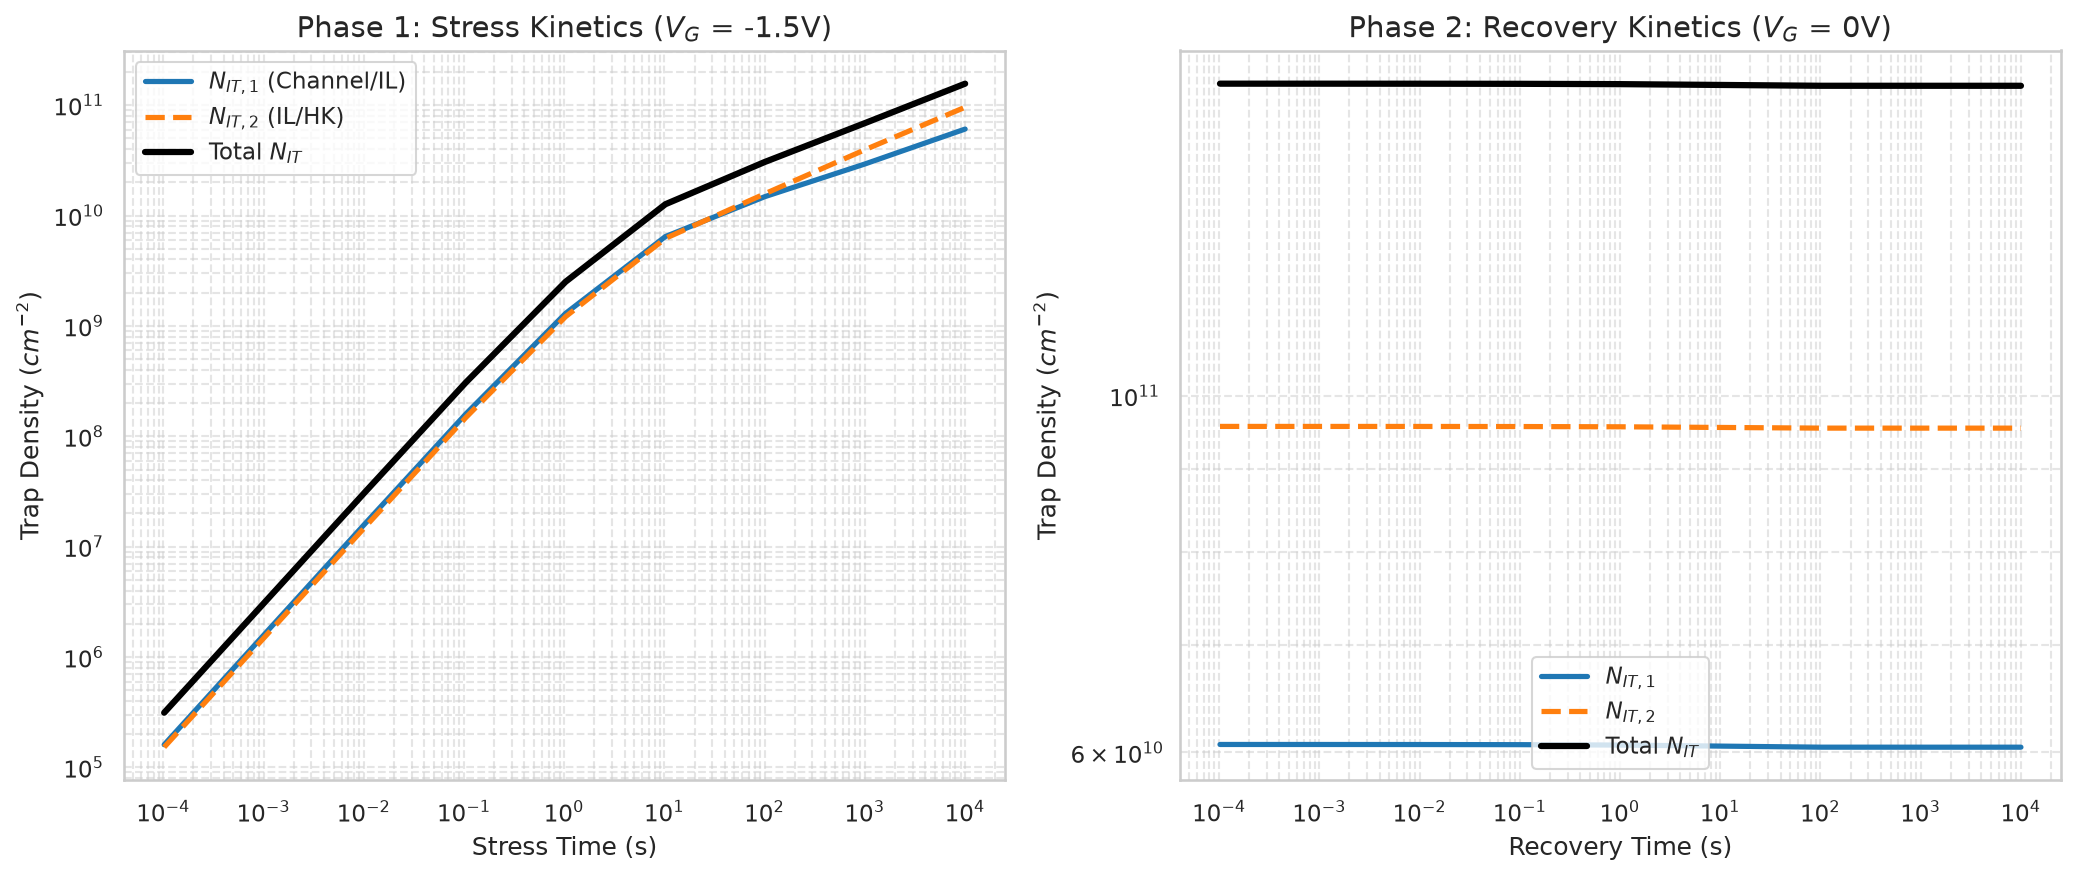
#### LOGS CAN BE ACCESSED HERE--https://rdmodel-2.vercel.app/time=10000s/L=30nm/non-reflective-zero-boundary

## Case 2 — 300 nm High-K with the Current Far-Boundary Condition

The High-K thickness was increased from 30 nm to 300 nm (Random obs by mistake🙃) while keeping the
reaction and Arrhenius parameters and the existing far-boundary condition
unchanged.

At 10,000 s stress:

- N_IT,1 = 2.98 × 10¹⁰ cm⁻²
- N_IT,2 = 4.01 × 10¹⁰ cm⁻²
- Total N_IT = 6.99 × 10¹⁰ cm⁻²

After 10,000 s of recovery:

- N_IT,1 = 1.89 × 10¹⁰ cm⁻²
- N_IT,2 = 2.92 × 10¹⁰ cm⁻²
- Total N_IT = 4.81 × 10¹⁰ cm⁻²

Compared with the 30 nm case, the predicted trap generation and recovery
behavior changes significantly when the High-K thickness is increased to
300 nm and similar plots were observed in earlier case with 30nm but reducing time to 100s.
And similar obs if we increse time that makes H to reach the baundary.

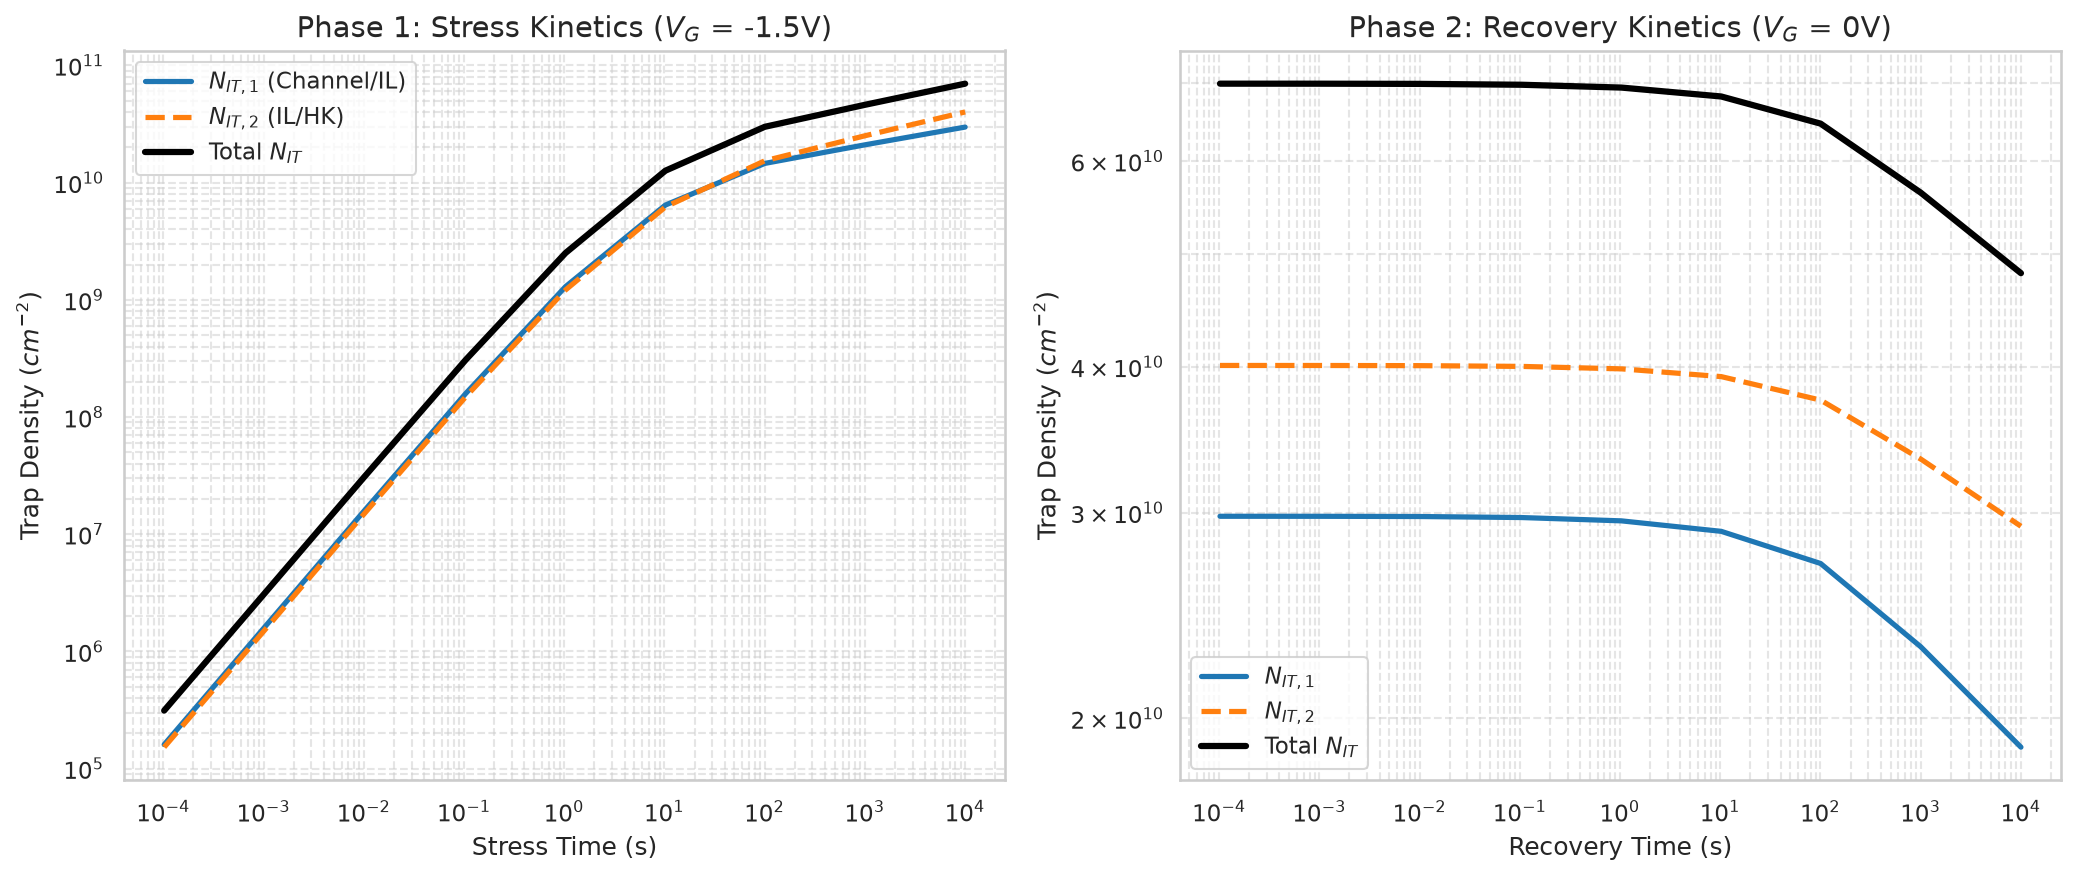

#### Logs https://rdmodel-2.vercel.app/time=10000s/L=300nm/non-reflective-zero-boundary

# Case 3 — 30 nm High-K with a Reflective H₂ Far-Boundary Condition

## Model configuration

- IL thickness: 1.5 nm
- High-K thickness: 30 nm
- Stress condition: V_G = −1.5 V
- Recovery condition: V_G = 0 V
- Temperature: 125 °C
- Stress duration: 10,000 s
- Recovery duration: 10,000 s
- Reaction and Arrhenius parameters: unchanged
- H₂ far boundary: reflective / zero-flux

## Observation

With the reflective far-boundary condition, the H₂ concentration is retained within the High-K region instead of being forced to zero at the far boundary.

The resulting trap generation during stress is approximately

N_IT1 = 1.57 × 10¹⁰ cm⁻²

N_IT2 = 1.65 × 10¹⁰ cm⁻²

N_IT,total = 3.23 × 10¹⁰ cm⁻²

During recovery, the total trap density decreases strongly:

- 7.46 × 10⁹ cm⁻² at 100 s
- 1.35 × 10⁶ cm⁻² at 1,000 s
- 2.87 × 10⁻¹ cm⁻² at 10,000 s

## Point requiring clarification

The reflective boundary gives a very different recovery behavior compared with the current 30 nm case.

The main uncertainty is therefore whether the far end of the 30 nm High-K region should be treated as an impermeable boundary, such as the metal gate/capping layer, or whether H₂ should be allowed to leave the simulated domain.

To compare the effect of this assumption, the three cases are:

- Case 1: 30 nm High-K with the current far-boundary condition.
- Case 2: 300 nm High-K with the same far-boundary condition.
- Case 3: 30 nm High-K with a reflective/zero-flux H₂ far boundary.

The purpose is to see how much the predicted stress and recovery behavior depends on the choice of the far-boundary condition.
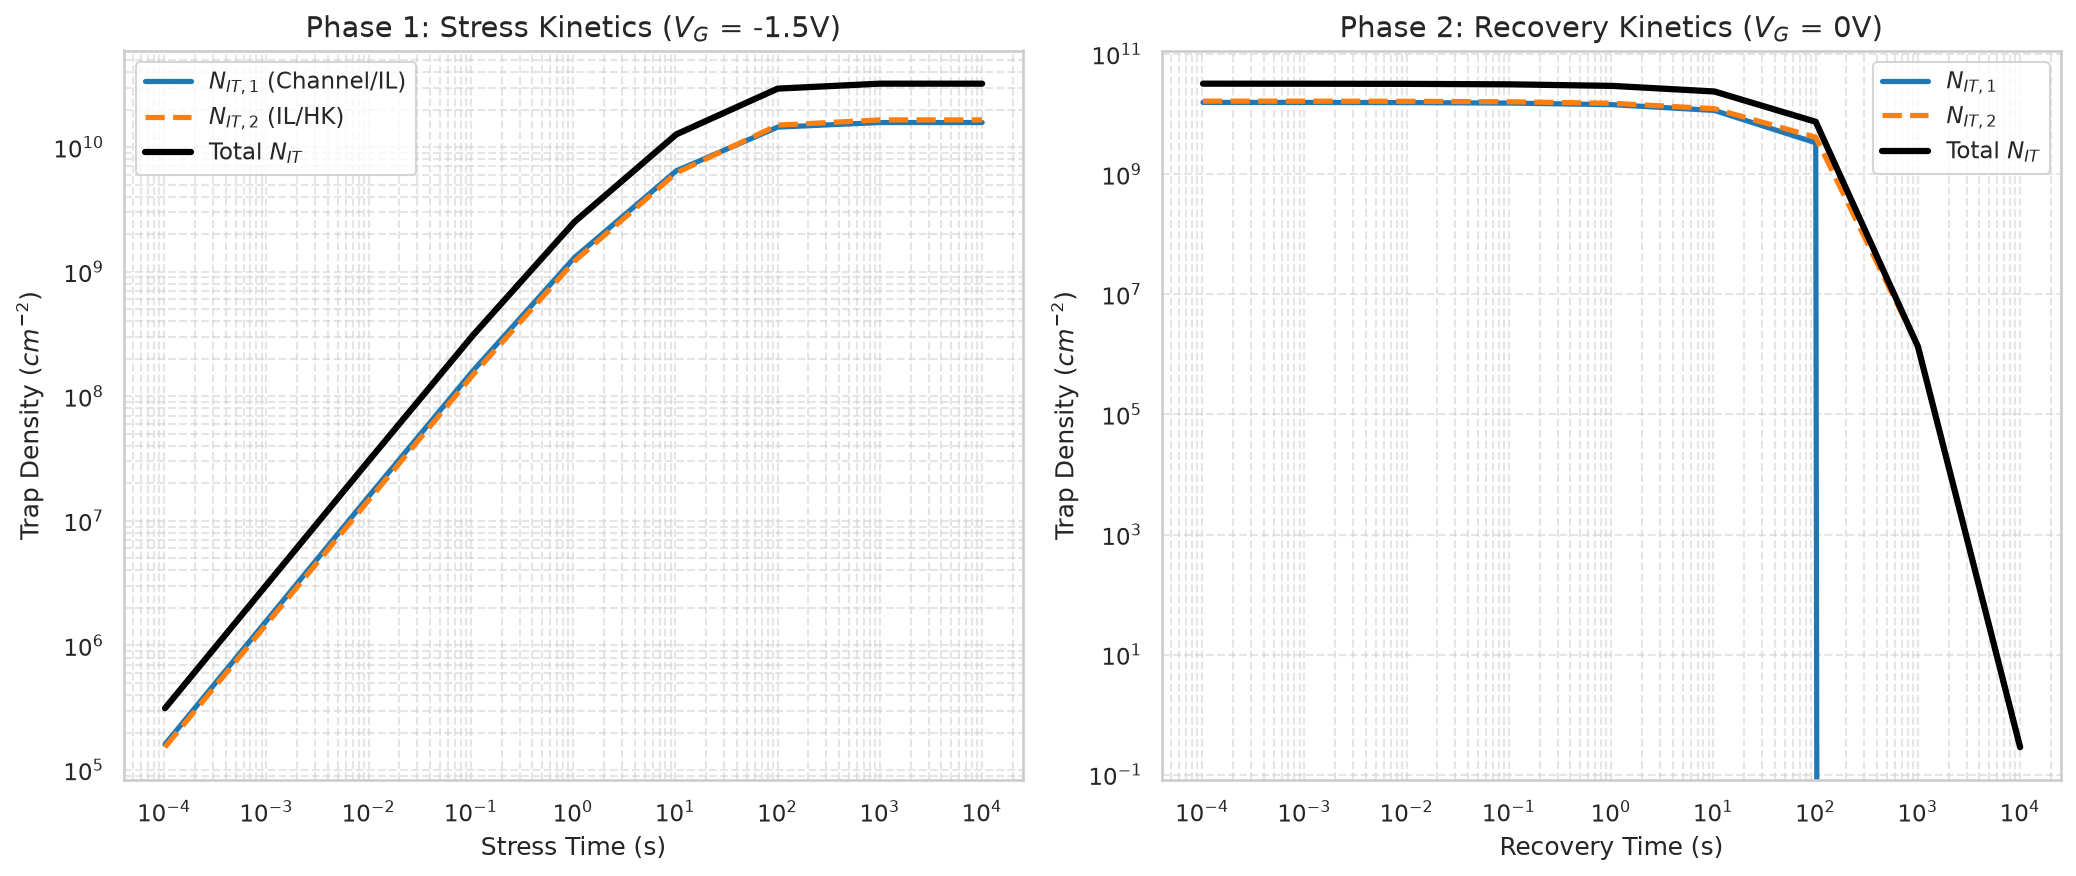
logs-https://rdmodel-2.vercel.app/T=100s/L=30nm#/main/time=10000s/L=30nm/reflective-boundary/T=125C/E=7MV

## Conclusion

The stress simulations show continuous trap generation, while the recovery behavior changes significantly depending on the assumed High-K thickness and far-boundary condition.

The results are sensitive to the treatment of the H₂ boundary, especially during recovery. I have made these simulations based on my best understanding of the available papers, book, model description, and the parameters available to me.

There may still be some misinterpretation of the physical model, parameter selection, boundary conditions, or coding implementation. Therefore, I have kept the different cases separate rather than choosing one condition directly.

The complete C implementation used for the simulations is available in the GitHub repository below:

https://github.com/SubratNit25/semiconductor-modeling

I would like to confirm these assumptions and the physical interpretation before proceeding with the final model.

### Interactive RD Model (Easy to build these days)

An interactive version of the RD simulation developed from the present C implementation is available here: clcik on the this. Play with it.

**[RD Model Interactive Simulation](https://rdmodel-2.vercel.app/)**

It provides a convenient way to vary simulation parameters and quickly visualize their effects on the stress and recovery behavior. Detailed logs can be accessed here.

In [11]:
// Python plot codes (will not work here in this kernel)
// import pandas as pd
// import matplotlib.pyplot as plt

// try:
//     df = pd.read_csv('rd_results.csv')
// except FileNotFoundError:
//     print("Error: 'rd_results.csv' not found. Run the C program first.")
//     exit()

// stress_df = df[df['Phase'] == 'Stress']
// recovery_df = df[df['Phase'] == 'Recovery']

// fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

// # Plot Phase 1: Stress
// ax1.plot(stress_df['Time'], stress_df['NIT1'], label=r'$N_{IT,1}$ (Channel/IL)', linewidth=2.5, color='#1f77b4')
// ax1.plot(stress_df['Time'], stress_df['NIT2'], label=r'$N_{IT,2}$ (IL/HK)', linewidth=2.5, linestyle='--', color='#ff7f0e')
// ax1.plot(stress_df['Time'], stress_df['Total_NIT'], label='Total $N_{IT}$', color='black', linewidth=3)

// ax1.set_xscale('log')
// ax1.set_yscale('log')
// ax1.set_title('Phase 1: Stress Kinetics ($V_G$ = -1.5V)', fontsize=14)
// ax1.set_xlabel('Stress Time (s)', fontsize=12)
// ax1.set_ylabel(r'Trap Density ($cm^{-2}$)', fontsize=12)
// ax1.grid(True, which="both", ls="--", alpha=0.5)
// ax1.legend(fontsize=11)

// # Plot Phase 2: Recovery
// ax2.plot(recovery_df['Time'], recovery_df['NIT1'], label=r'$N_{IT,1}$', linewidth=2.5, color='#1f77b4')
// ax2.plot(recovery_df['Time'], recovery_df['NIT2'], label=r'$N_{IT,2}$', linewidth=2.5, linestyle='--', color='#ff7f0e')
// ax2.plot(recovery_df['Time'], recovery_df['Total_NIT'], label='Total $N_{IT}$', color='black', linewidth=3)

// ax2.set_xscale('log')
// ax2.set_yscale('log')
// ax2.set_title('Phase 2: Recovery Kinetics ($V_G$ = 0V)', fontsize=14)
// ax2.set_xlabel('Recovery Time (s)', fontsize=12)
// ax2.set_ylabel(r'Trap Density ($cm^{-2}$)', fontsize=12)
// ax2.grid(True, which="both", ls="--", alpha=0.5)
// ax2.legend(fontsize=11)

// plt.tight_layout()
// plt.show()

ERROR: received unknown message
Message type: usage_request
ERROR: received bad message: No such comm registered: 5914f962-de0b-4cdf-80e7-7ff8eb976711
Message type: comm_msg
ERROR: received bad message: No such comm registered: 385aea36-f771-4ba5-a89e-8da8507a3ff7
Message type: comm_msg
ERROR: received bad message: No such comm registered: f10bde05-b9ad-4ba0-a90c-893f410474b5
Message type: comm_msg
ERROR: received bad message: No such comm registered: f491dead-61bd-4cf4-8e42-073073c4d6e3
Message type: comm_msg
ERROR: received bad message: No such comm registered: f5a39e3c-b56b-4b41-8aa2-b87c268037f3
Message type: comm_msg
